In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("diabetic_data_clean.csv")
print("Dataset loaded successfully")
print("shape:",df.shape)

C:\Users\user\AppData\Local\Temp\ipykernel_27992\2908859170.py:1: DtypeWarning: Columns (7: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("diabetic_data_clean.csv")


Dataset loaded successfully
shape: (101766, 47)


In [3]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,NaN,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,NaN,NaN,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,NaN,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,NaN,NaN,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,NaN,NaN,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.tail()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,AfricanAmerican,Male,[70-80),1,3,7,3,MC,NaN,51,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,AfricanAmerican,Female,[80-90),1,4,5,5,MC,NaN,33,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,Caucasian,Male,[70-80),1,1,7,1,MC,NaN,53,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,Caucasian,Female,[80-90),2,3,7,10,MC,Surgery-General,45,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,Caucasian,Male,[70-80),1,1,7,6,NaN,NaN,13,...,No,No,No,No,No,No,No,No,No,NO


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      99493 non-null   str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   admission_type_id         101766 non-null  int64
 4   discharge_disposition_id  101766 non-null  int64
 5   admission_source_id       101766 non-null  int64
 6   time_in_hospital          101766 non-null  int64
 7   payer_code                61510 non-null   str  
 8   medical_specialty         51817 non-null   str  
 9   num_lab_procedures        101766 non-null  int64
 10  num_procedures            101766 non-null  int64
 11  num_medications           101766 non-null  int64
 12  number_outpatient         101766 non-null  int64
 13  number_emergency          101766 non-null  int64
 14  number_inpatient          10176

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0


In [7]:
missing=df.isnull().sum()

In [8]:
missing_df=pd.DataFrame({
    'Column': missing.index,
    'Missing_Count':missing.values,
    'Missing_Percentage': (missing.values/len(df))*100
})

missing_df=missing_df[missing_df['Missing_Count']>0]
missing_df=missing_df.sort_values(by='Missing_Percentage',ascending=False)

missing_df

,Column,Missing_Count,Missing_Percentage
19,max_glu_serum,96420,94.746772
20,A1Cresult,84748,83.277322
8,medical_specialty,49949,49.082208
7,payer_code,40256,39.557416
0,race,2273,2.233555
17,diag_3,1423,1.398306
16,diag_2,358,0.351787
15,diag_1,21,0.020636


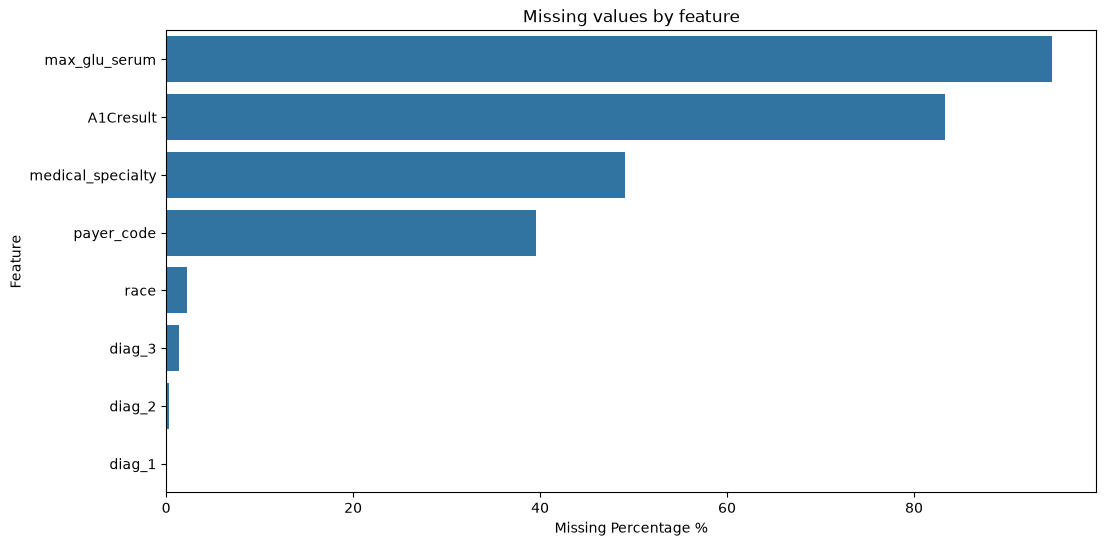

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(data=missing_df,x='Missing_Percentage',y='Column')
plt.title("Missing values by feature")
plt.xlabel("Missing Percentage %")
plt.ylabel("Feature")
plt.show()

In [10]:
target_counts=df['readmitted'].value_counts()
target_counts

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [11]:
target_percentage=df['readmitted'].value_counts(normalize=True)*100
target_percentage.round(2)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

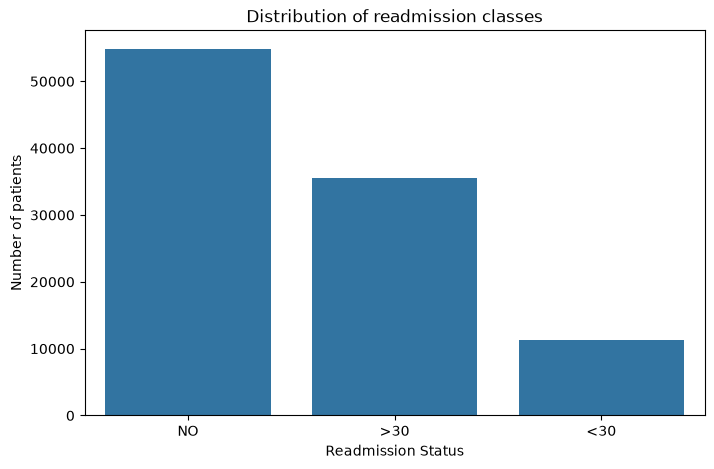

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df,x='readmitted',order=df['readmitted'].value_counts().index)

plt.title("Distribution of readmission classes")
plt.xlabel("Readmission Status")
plt.ylabel("Number of patients")
plt.show()

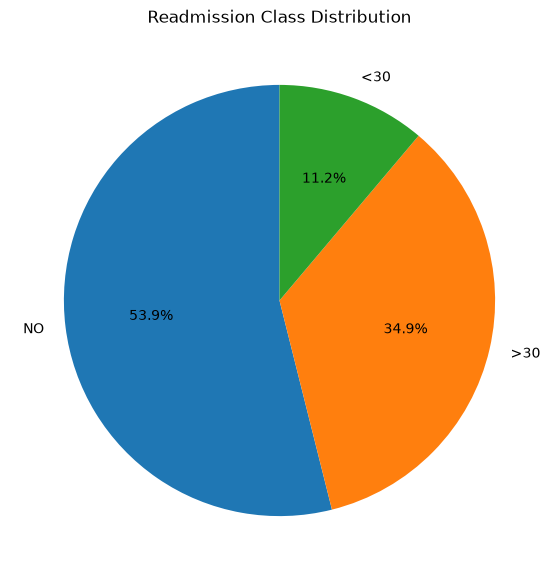

In [13]:
plt.figure(figsize=(7, 7))

df['readmitted'].value_counts().plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.title("Readmission Class Distribution")
plt.ylabel("")

plt.show()

In [14]:
numerical_cols=df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Number of numerical features:",len(numerical_cols))
print(numerical_cols)

Number of numerical features: 11
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


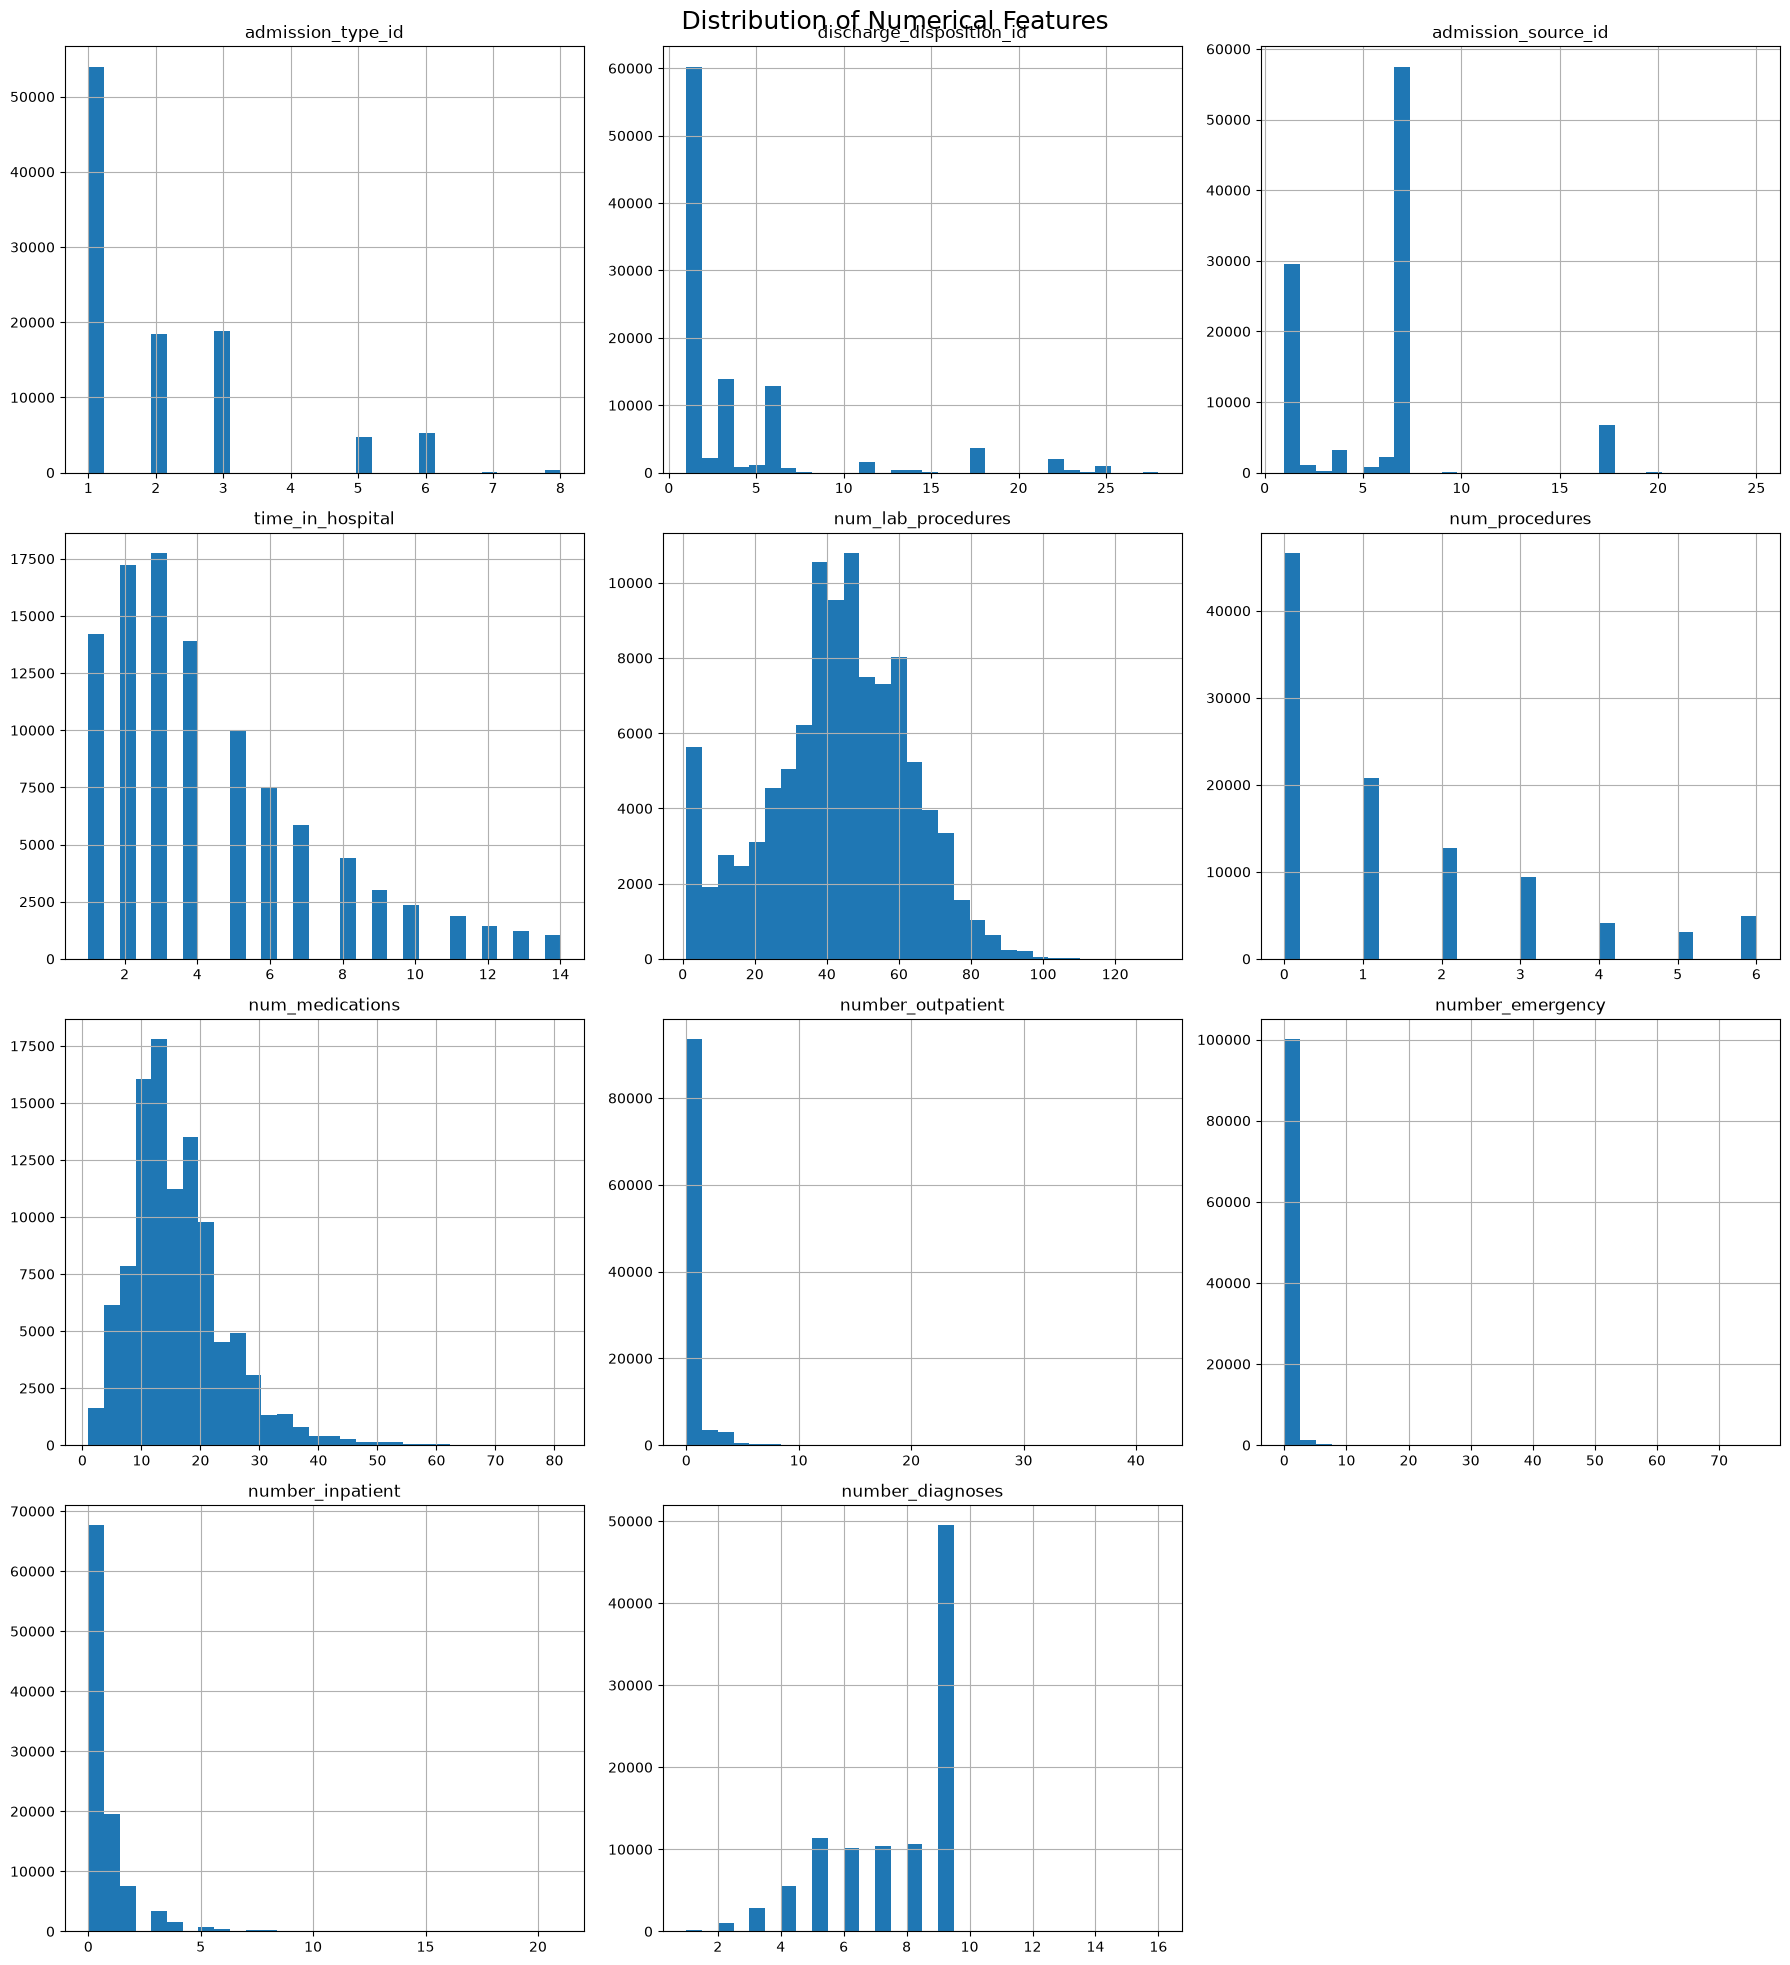

In [15]:
df[numerical_cols].hist(figsize=(18, 20),bins=30)
plt.suptitle("Distribution of Numerical Features",fontsize=18)

plt.tight_layout()
plt.show()

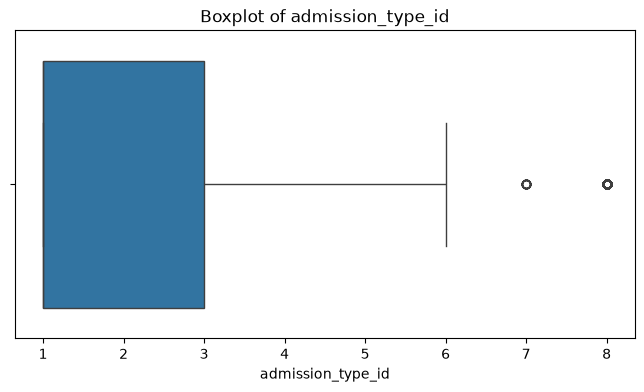

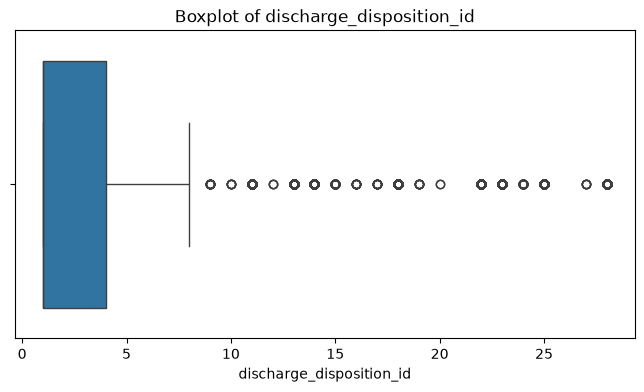

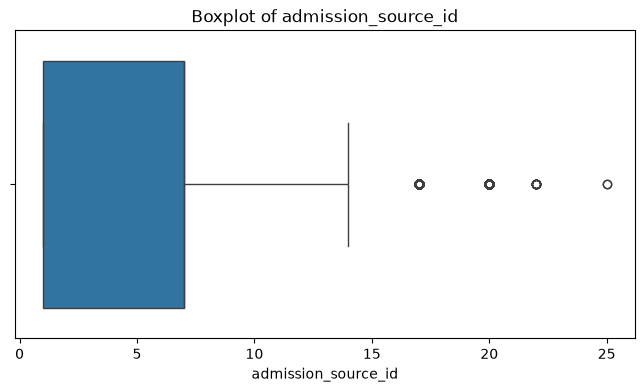

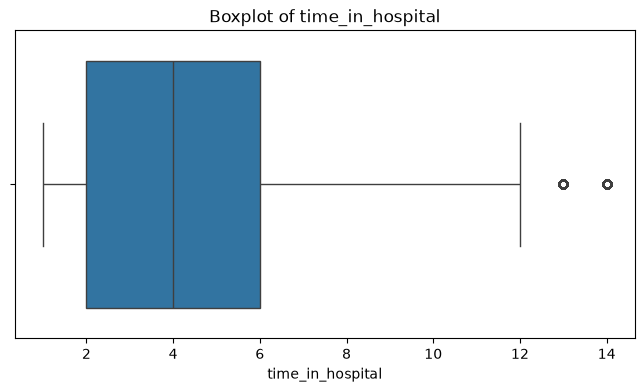

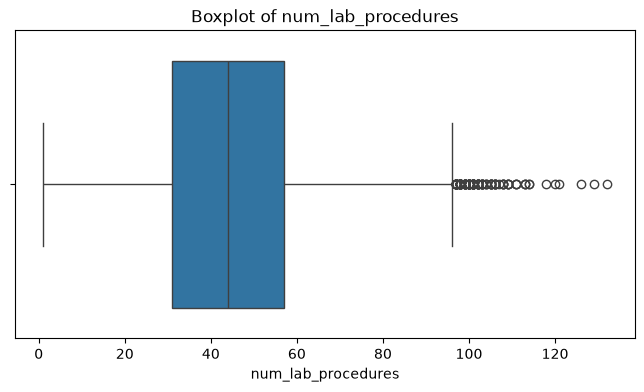

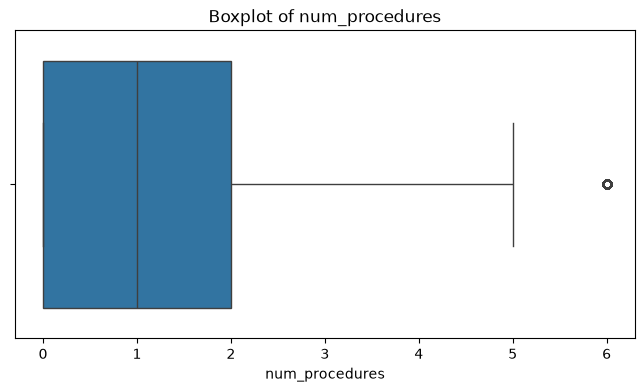

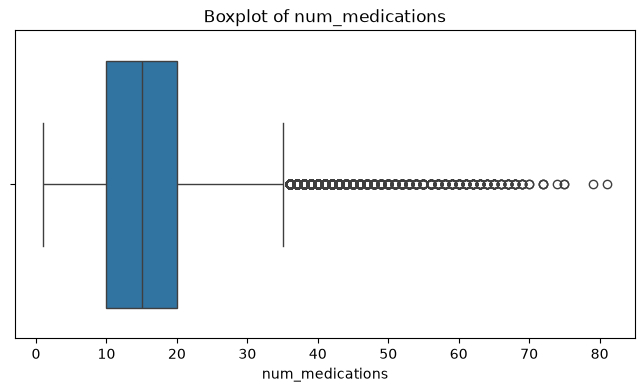

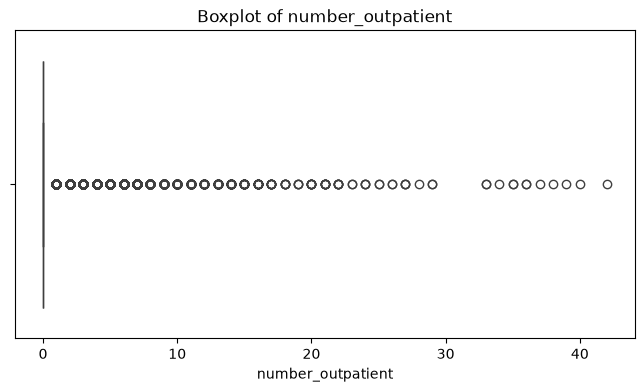

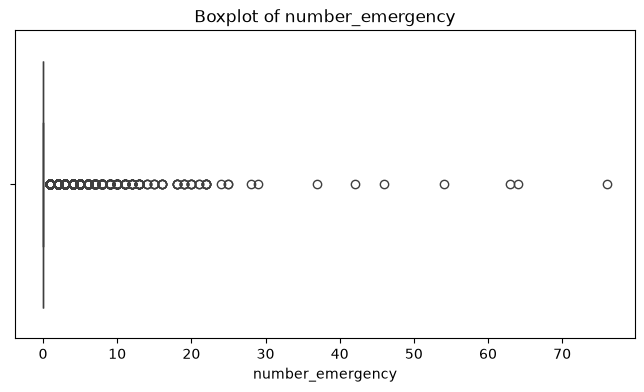

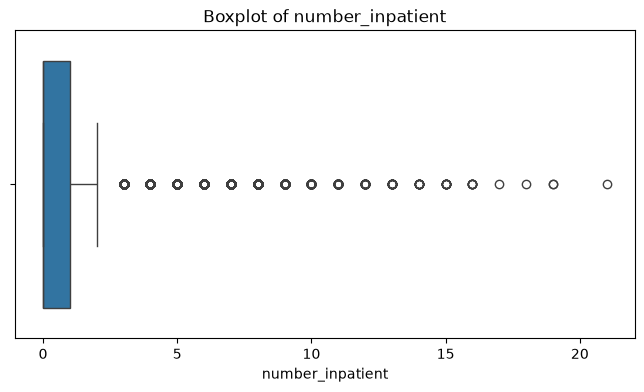

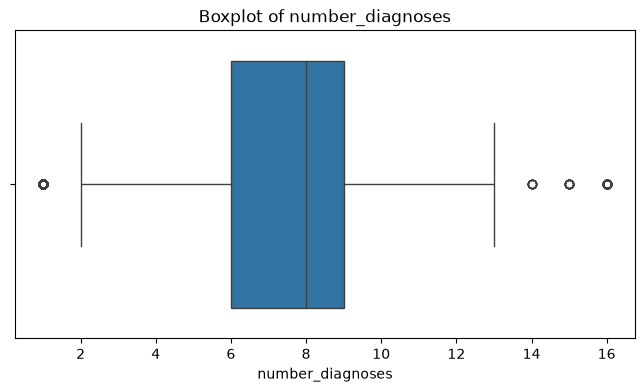

In [16]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

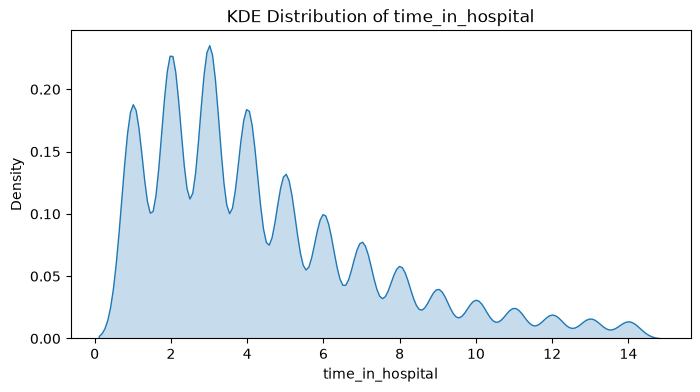

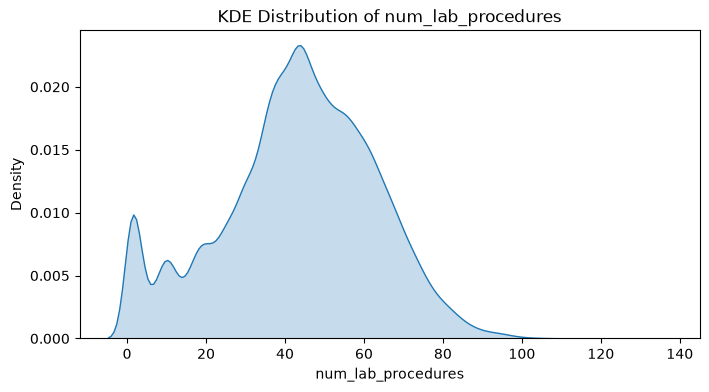

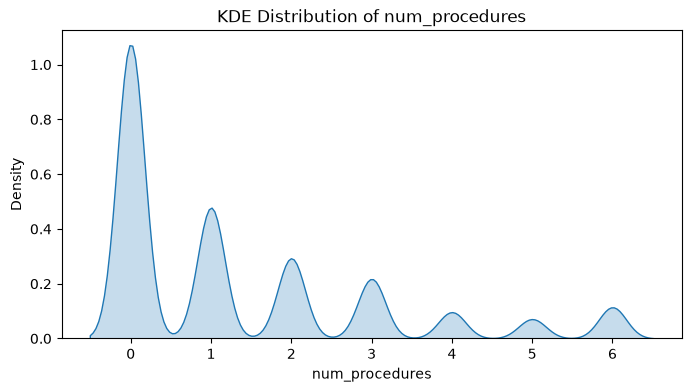

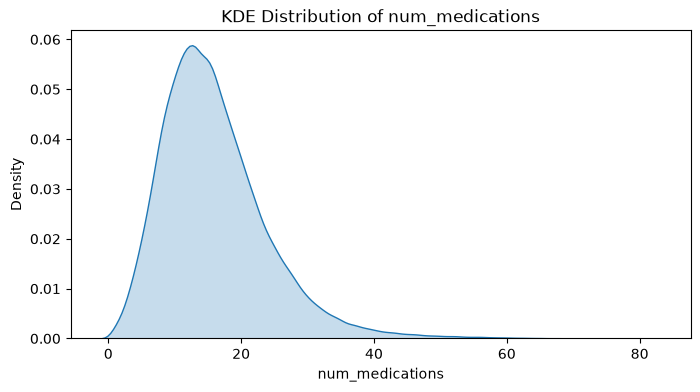

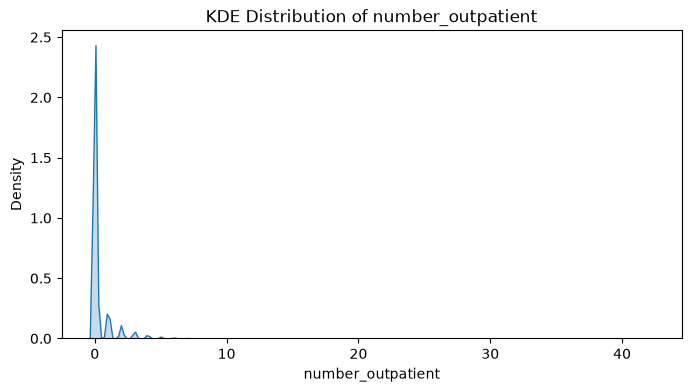

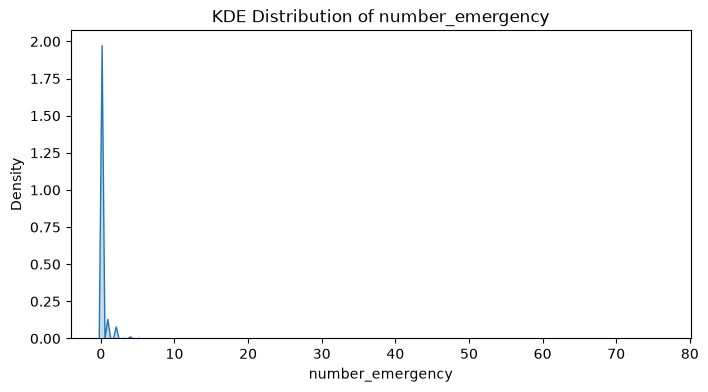

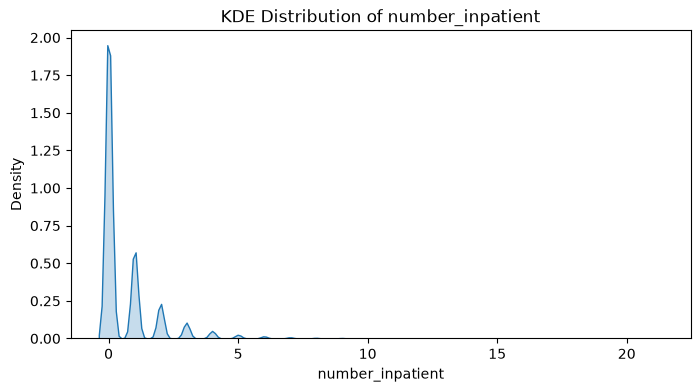

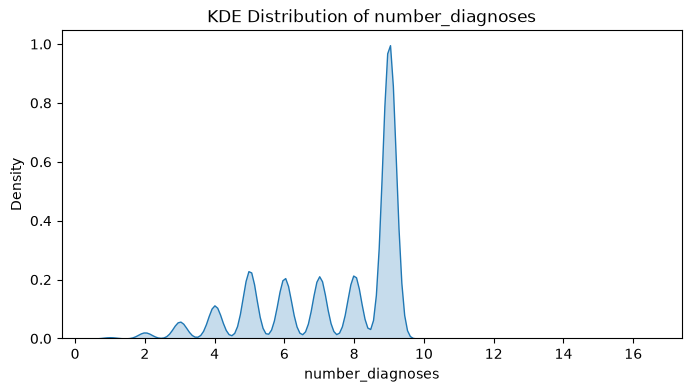

In [17]:
selected_kde_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

for col in selected_kde_cols:
    plt.figure(figsize=(8, 4))
    
    sns.kdeplot(data=df,x=col,fill=True)
    
    plt.title(f"KDE Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    
    plt.show()

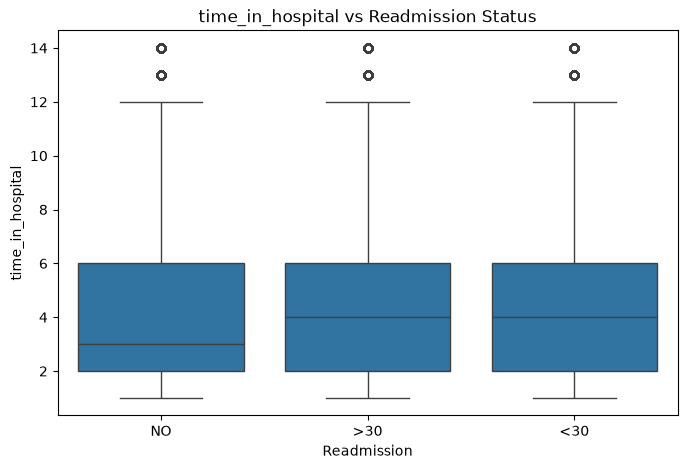

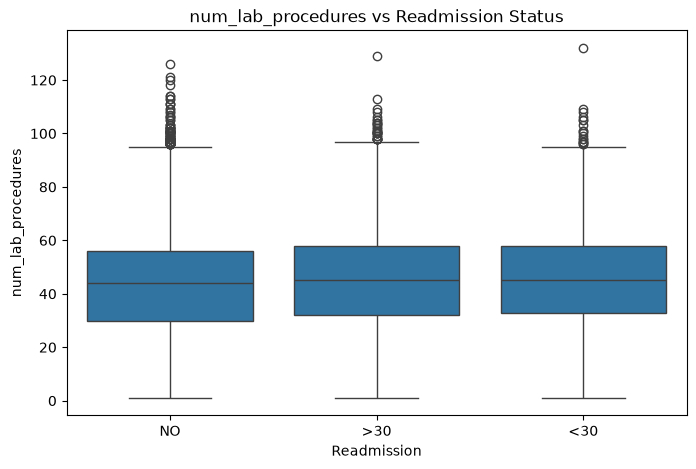

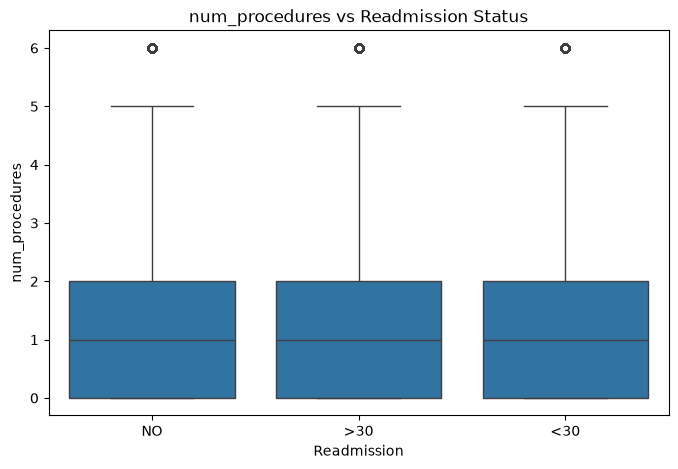

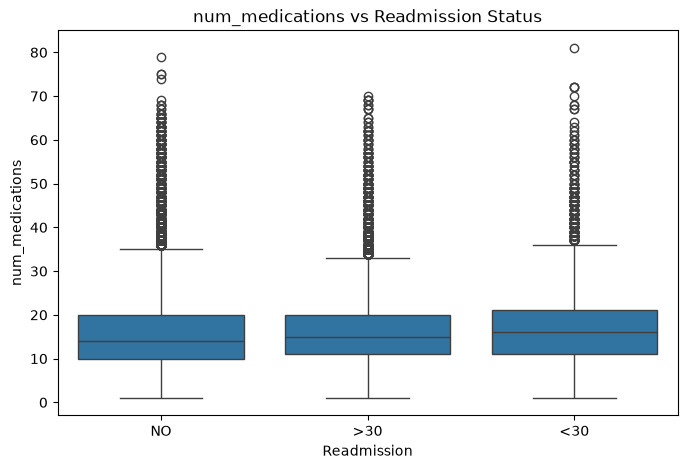

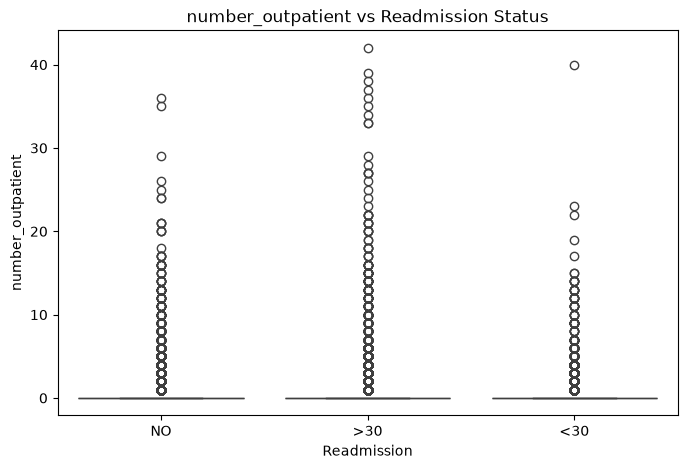

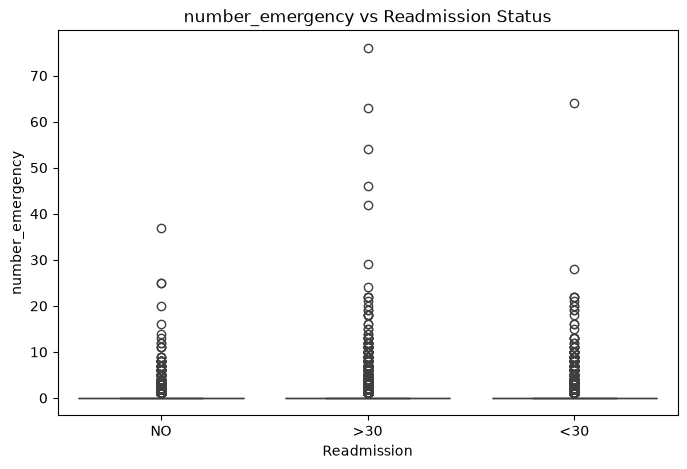

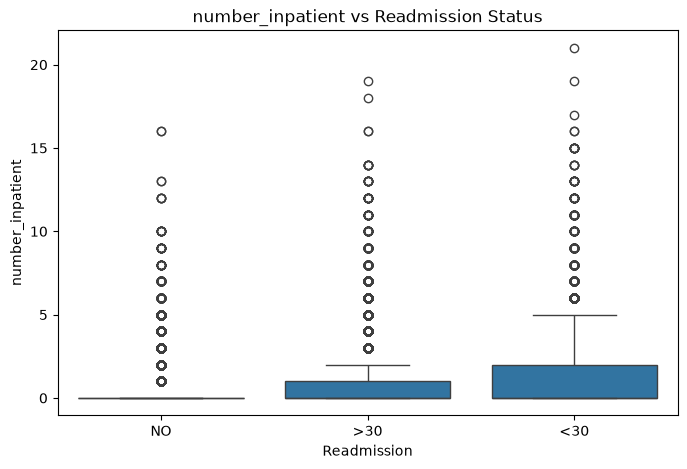

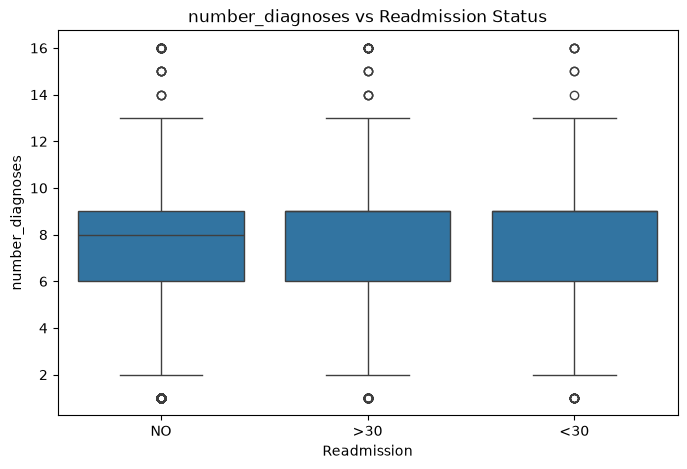

In [18]:
for col in selected_kde_cols:
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df,x='readmitted',y=col)
    
    plt.title(f"{col} vs Readmission Status")
    plt.xlabel("Readmission")
    plt.ylabel(col)
    
    plt.show()

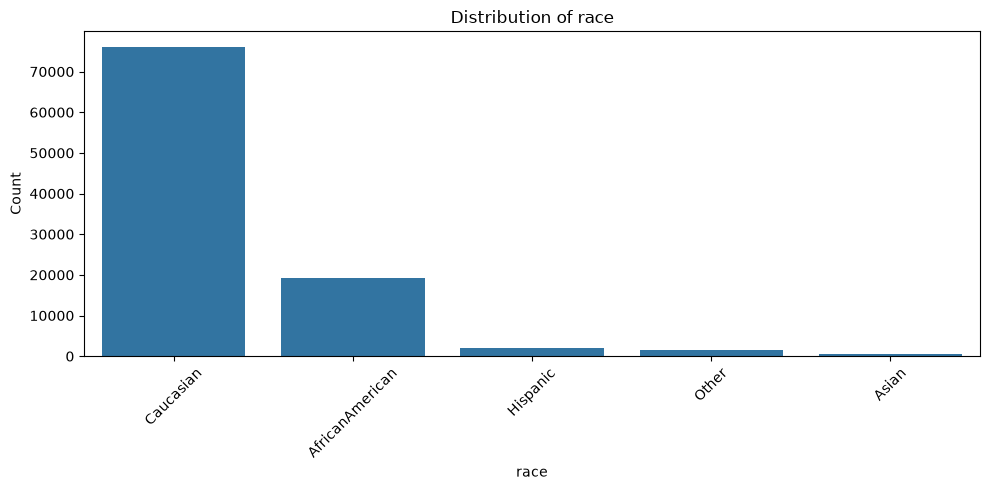

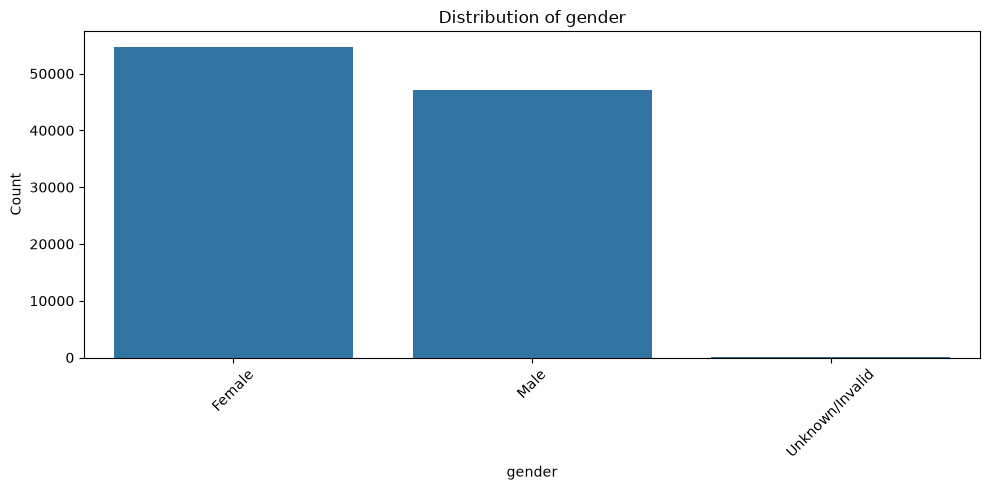

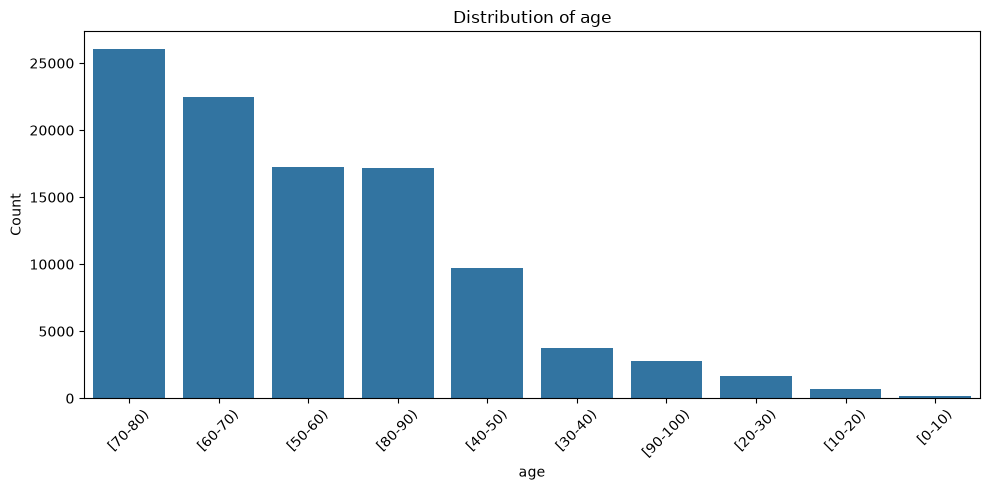

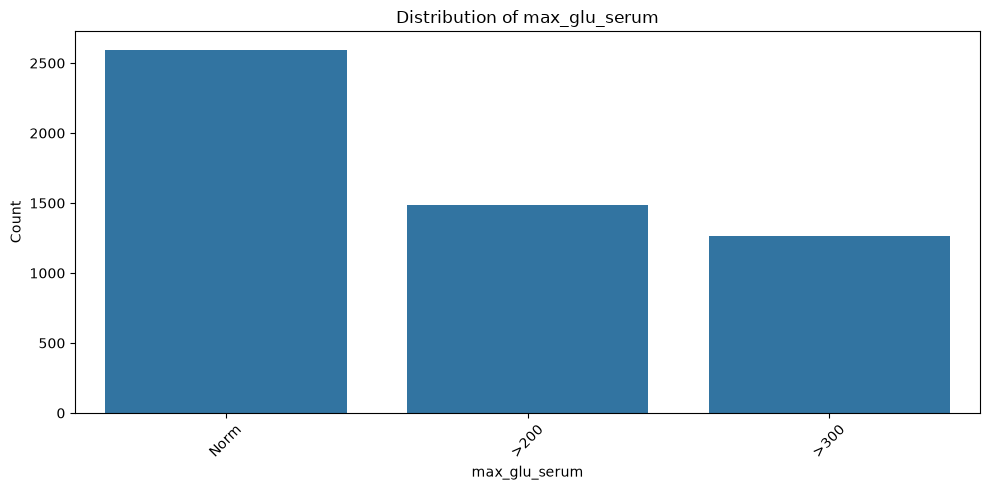

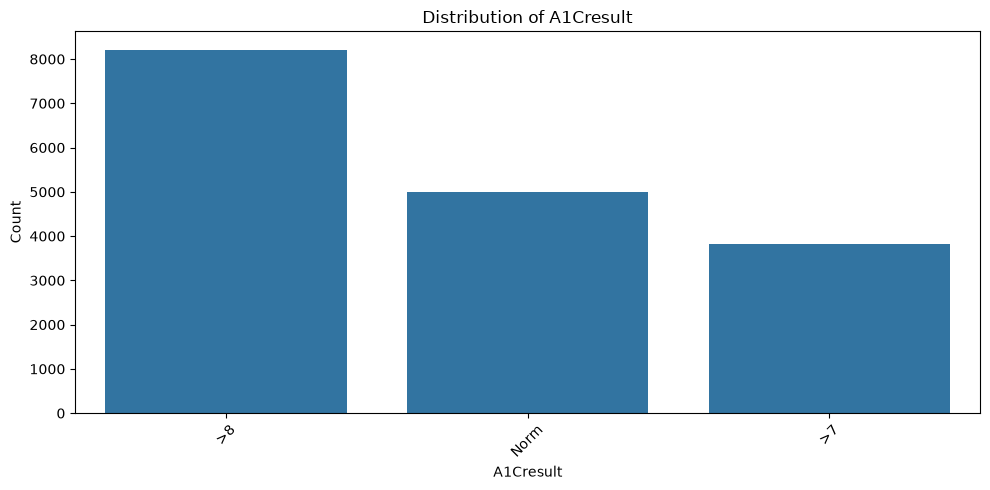

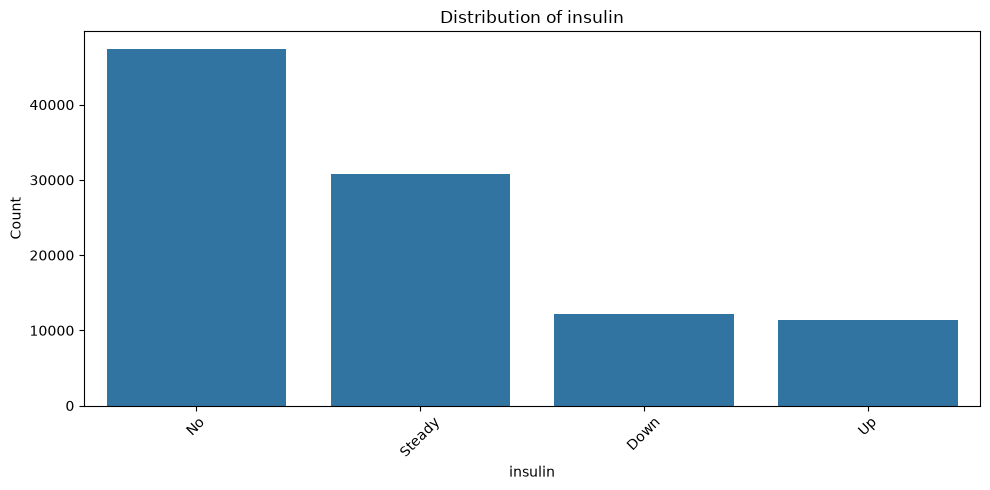

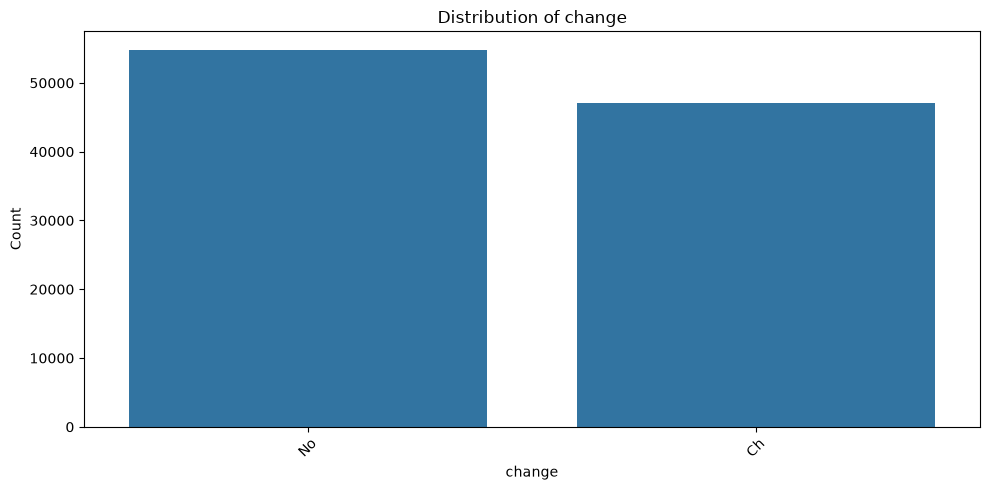

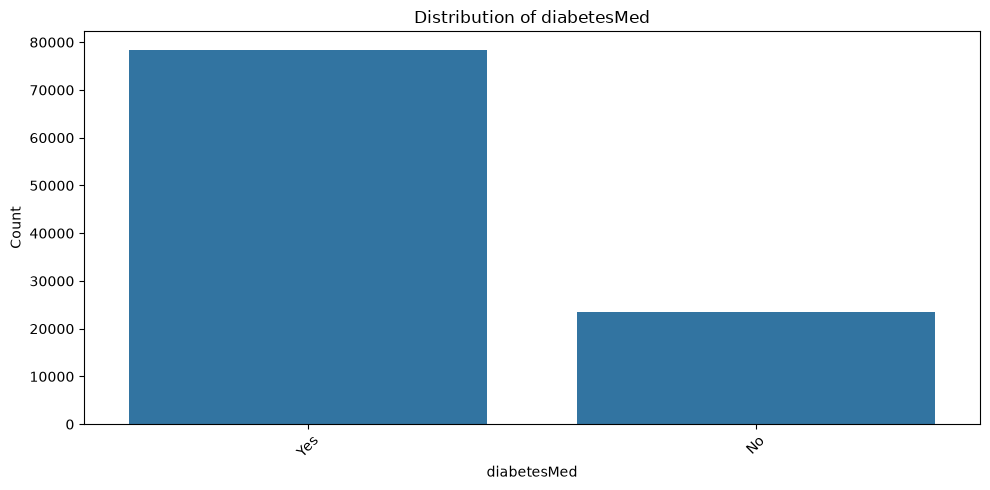

In [19]:
selected_categorical_cols=['race','gender','age','max_glu_serum','A1Cresult','insulin','change','diabetesMed']

for col in selected_categorical_cols:
    plt.figure(figsize=(10, 5))
    order=df[col].value_counts().index
    
    sns.countplot(data=df,x=col,order=order)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

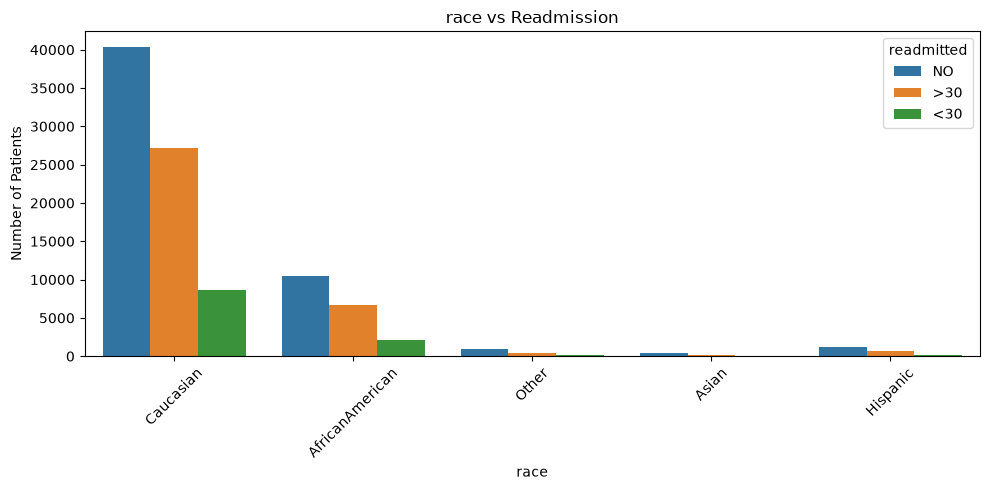

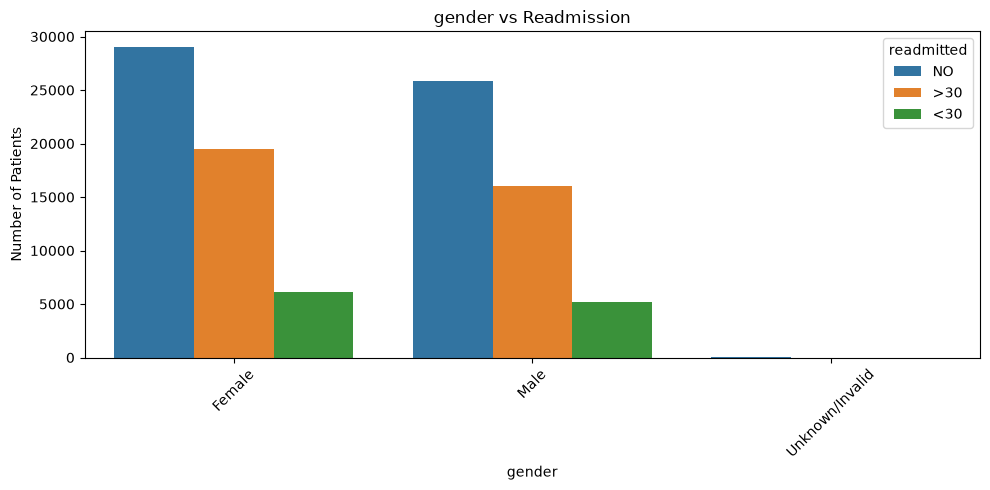

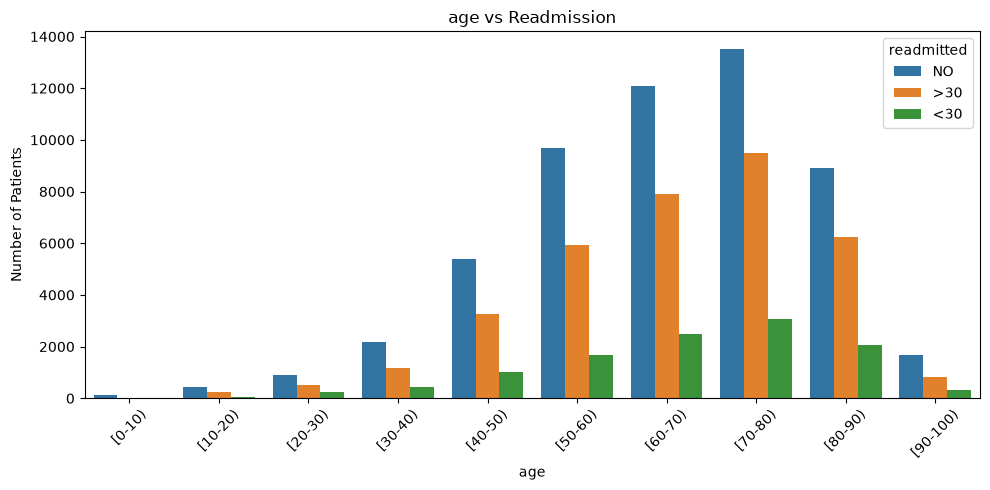

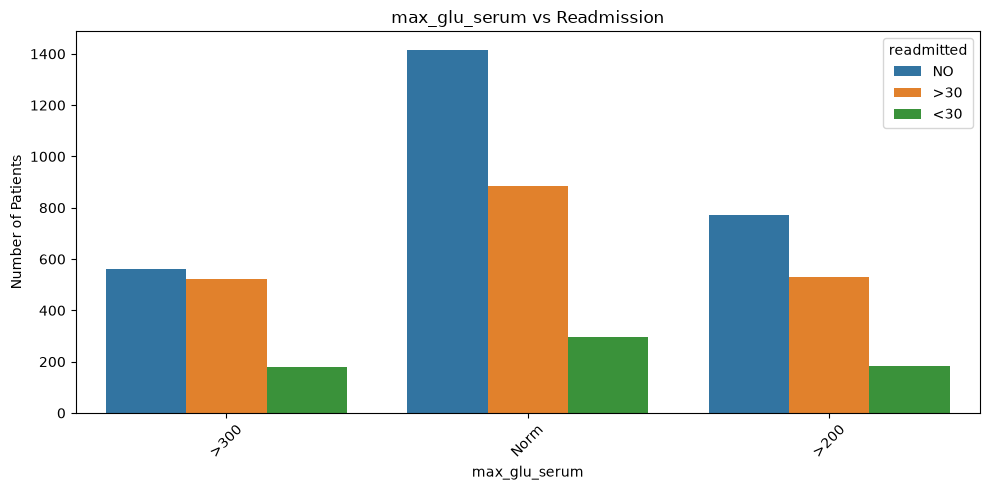

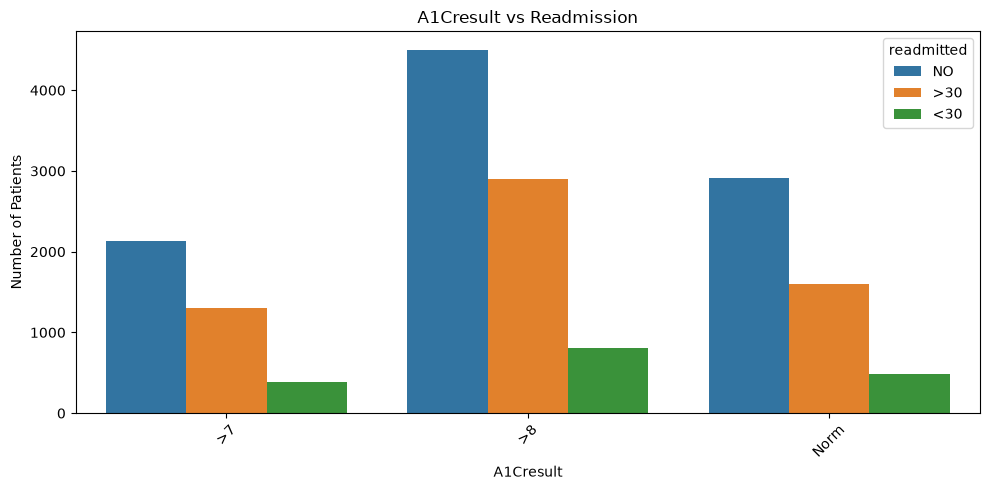

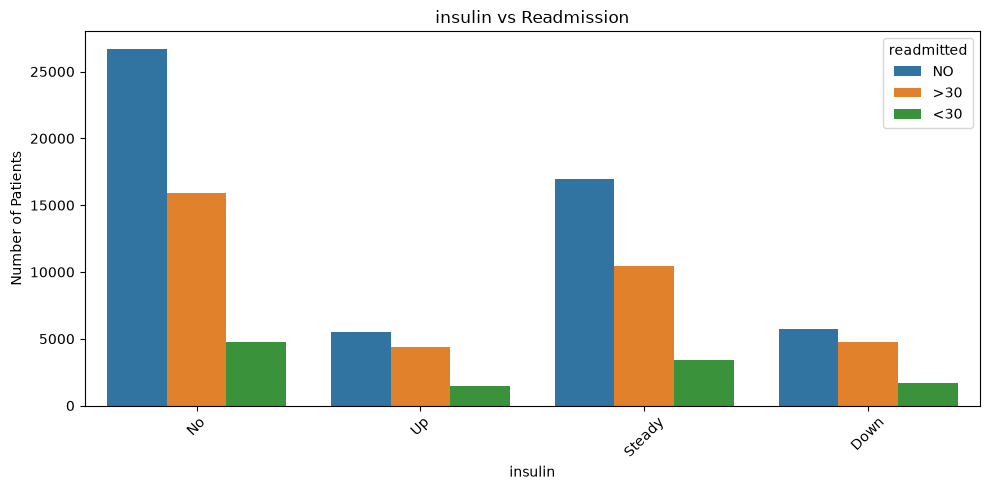

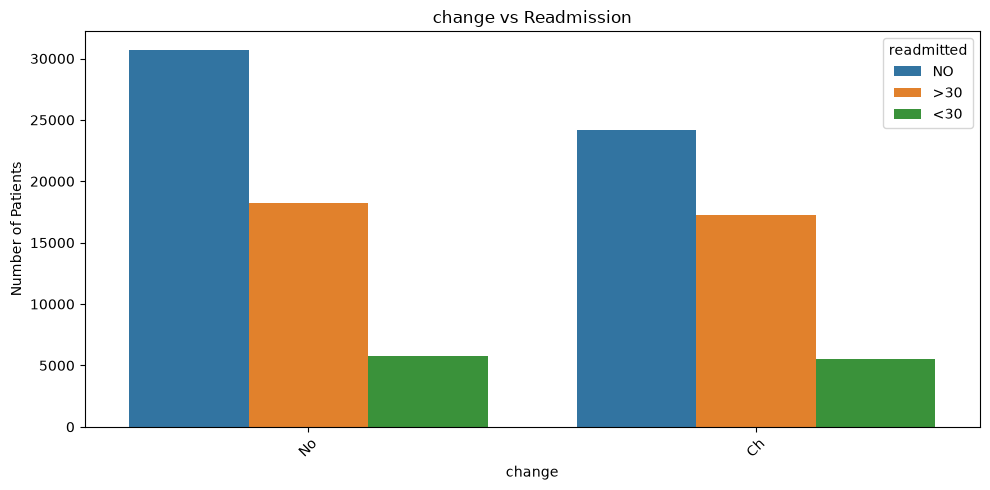

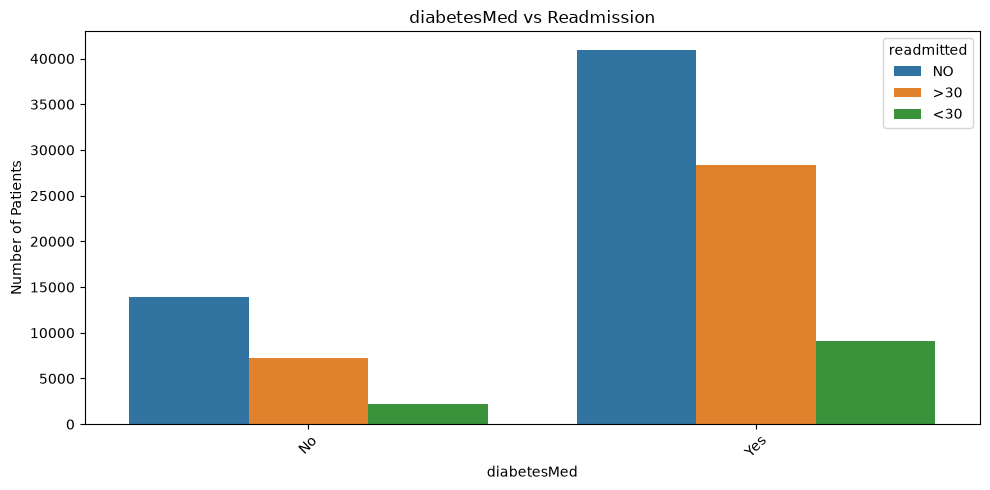

In [20]:
for col in selected_categorical_cols:
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df,x=col,hue='readmitted')
    
    plt.title(f"{col} vs Readmission")
    plt.xlabel(col)
    plt.ylabel("Number of Patients")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

In [21]:
age_readmission=pd.crosstab(df['age'],df['readmitted'],normalize='index')*100
age_readmission

readmitted,<30,>30,NO
age,,,
[0-10),1.863354,16.149068,81.987578
[10-20),5.788712,32.416787,61.794501
[20-30),14.242607,30.778515,54.978877
[30-40),11.231788,31.443709,57.324503
[40-50),10.604027,33.846154,55.549819
[50-60),9.666203,34.289522,56.044274
[60-70),11.128408,35.124316,53.747276
[70-80),11.773055,36.347246,51.879699
[80-90),12.083503,36.186544,51.729953


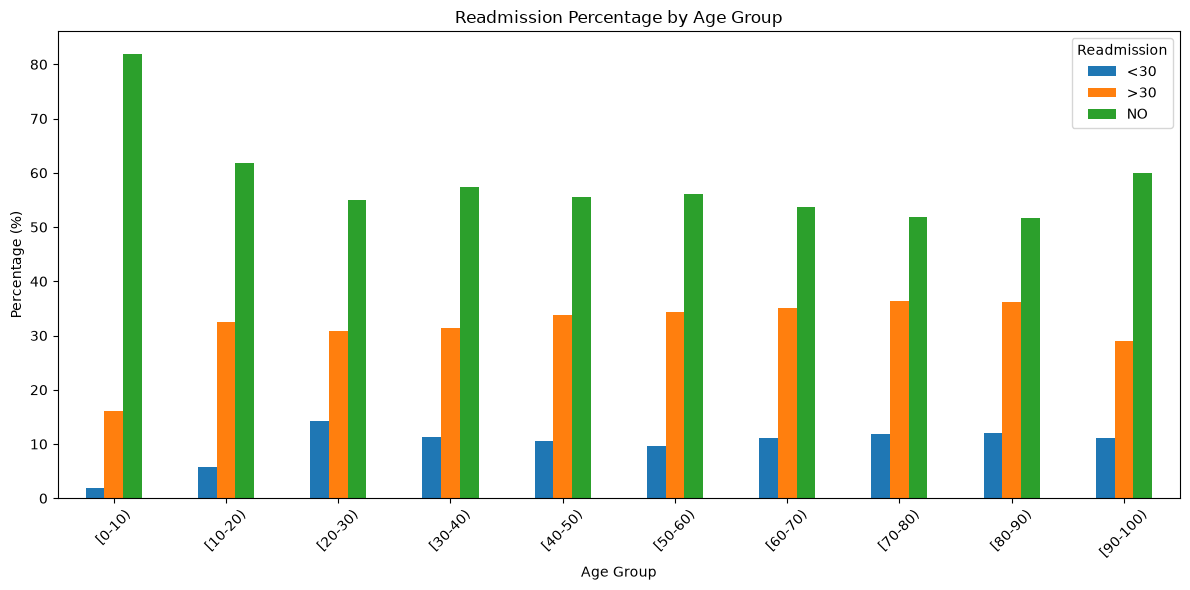

In [22]:
age_readmission.plot(kind='bar',figsize=(12, 6))

plt.title("Readmission Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)
plt.legend(title="Readmission")

plt.tight_layout()
plt.show()

In [23]:
correlation_matrix=df[numerical_cols].corr()
correlation_matrix

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
admission_type_id,1.000000,0.083483,0.106654,-0.012500,-0.143713,0.129888,0.079535,0.026511,-0.019116,-0.038161,-0.117126
discharge_disposition_id,0.083483,1.000000,0.018193,0.162748,0.023415,0.015921,0.108753,-0.008715,-0.024471,0.020787,0.046891
admission_source_id,0.106654,0.018193,1.000000,-0.006965,0.048885,-0.135400,-0.054533,0.027244,0.059892,0.036314,0.072114
time_in_hospital,-0.012500,0.162748,-0.006965,1.000000,0.318450,0.191472,0.466135,-0.008916,-0.009681,0.073623,0.220186
num_lab_procedures,-0.143713,0.023415,0.048885,0.318450,1.000000,0.058066,0.268161,-0.007602,-0.002279,0.039231,0.152773
num_procedures,0.129888,0.015921,-0.135400,0.191472,0.058066,1.000000,0.385767,-0.024819,-0.038179,-0.066236,0.073734
num_medications,0.079535,0.108753,-0.054533,0.466135,0.268161,0.385767,1.000000,0.045197,0.013180,0.064194,0.261526
number_outpatient,0.026511,-0.008715,0.027244,-0.008916,-0.007602,-0.024819,0.045197,1.000000,0.091459,0.107338,0.094152
number_emergency,-0.019116,-0.024471,0.059892,-0.009681,-0.002279,-0.038179,0.013180,0.091459,1.000000,0.266559,0.055539
number_inpatient,-0.038161,0.020787,0.036314,0.073623,0.039231,-0.066236,0.064194,0.107338,0.266559,1.000000,0.104710


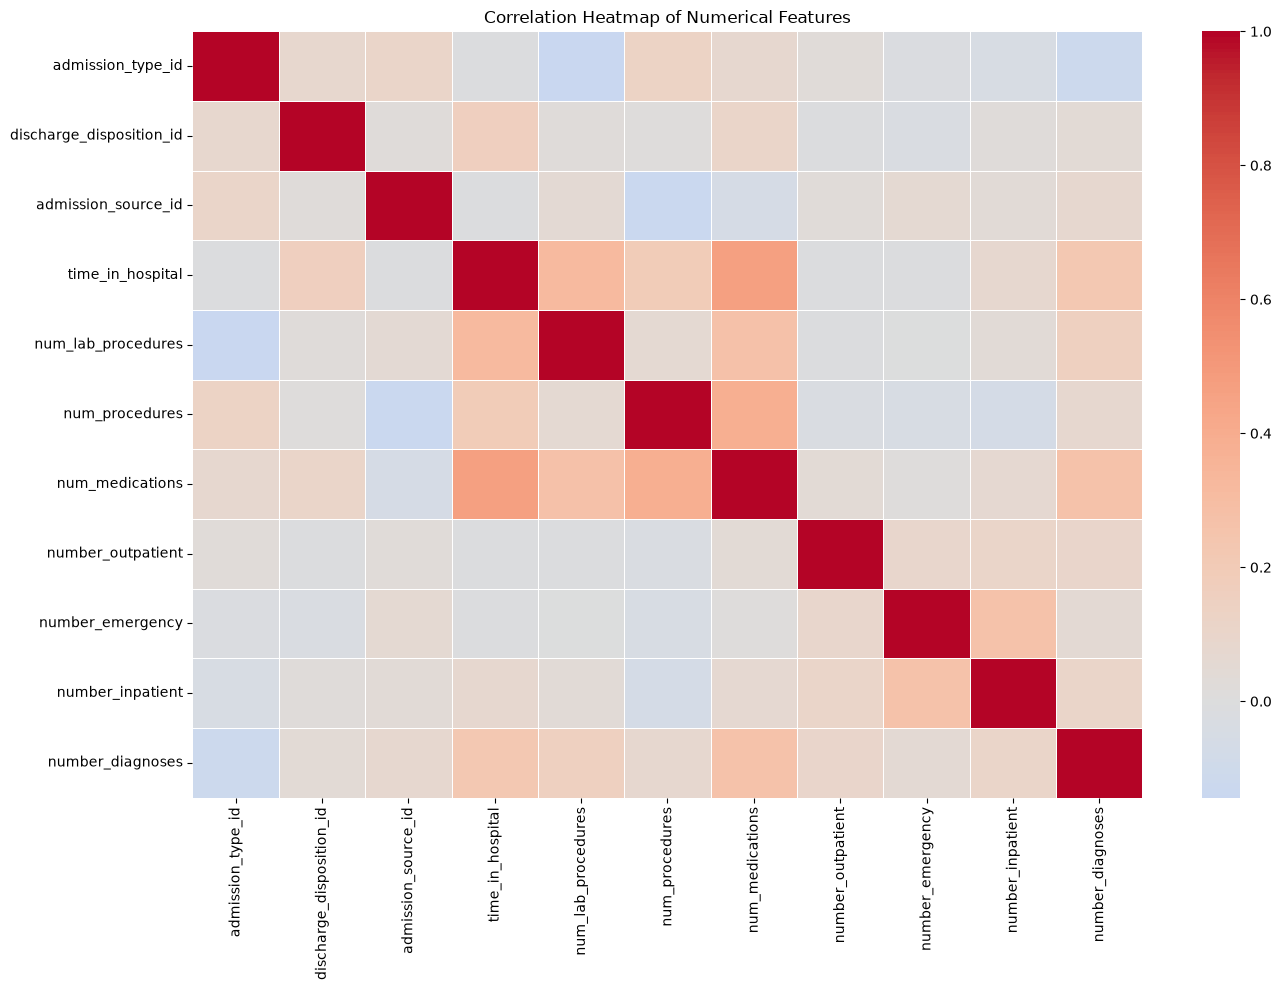

In [24]:
plt.figure(figsize=(14, 10))

sns.heatmap(correlation_matrix,cmap='coolwarm',center=0,linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

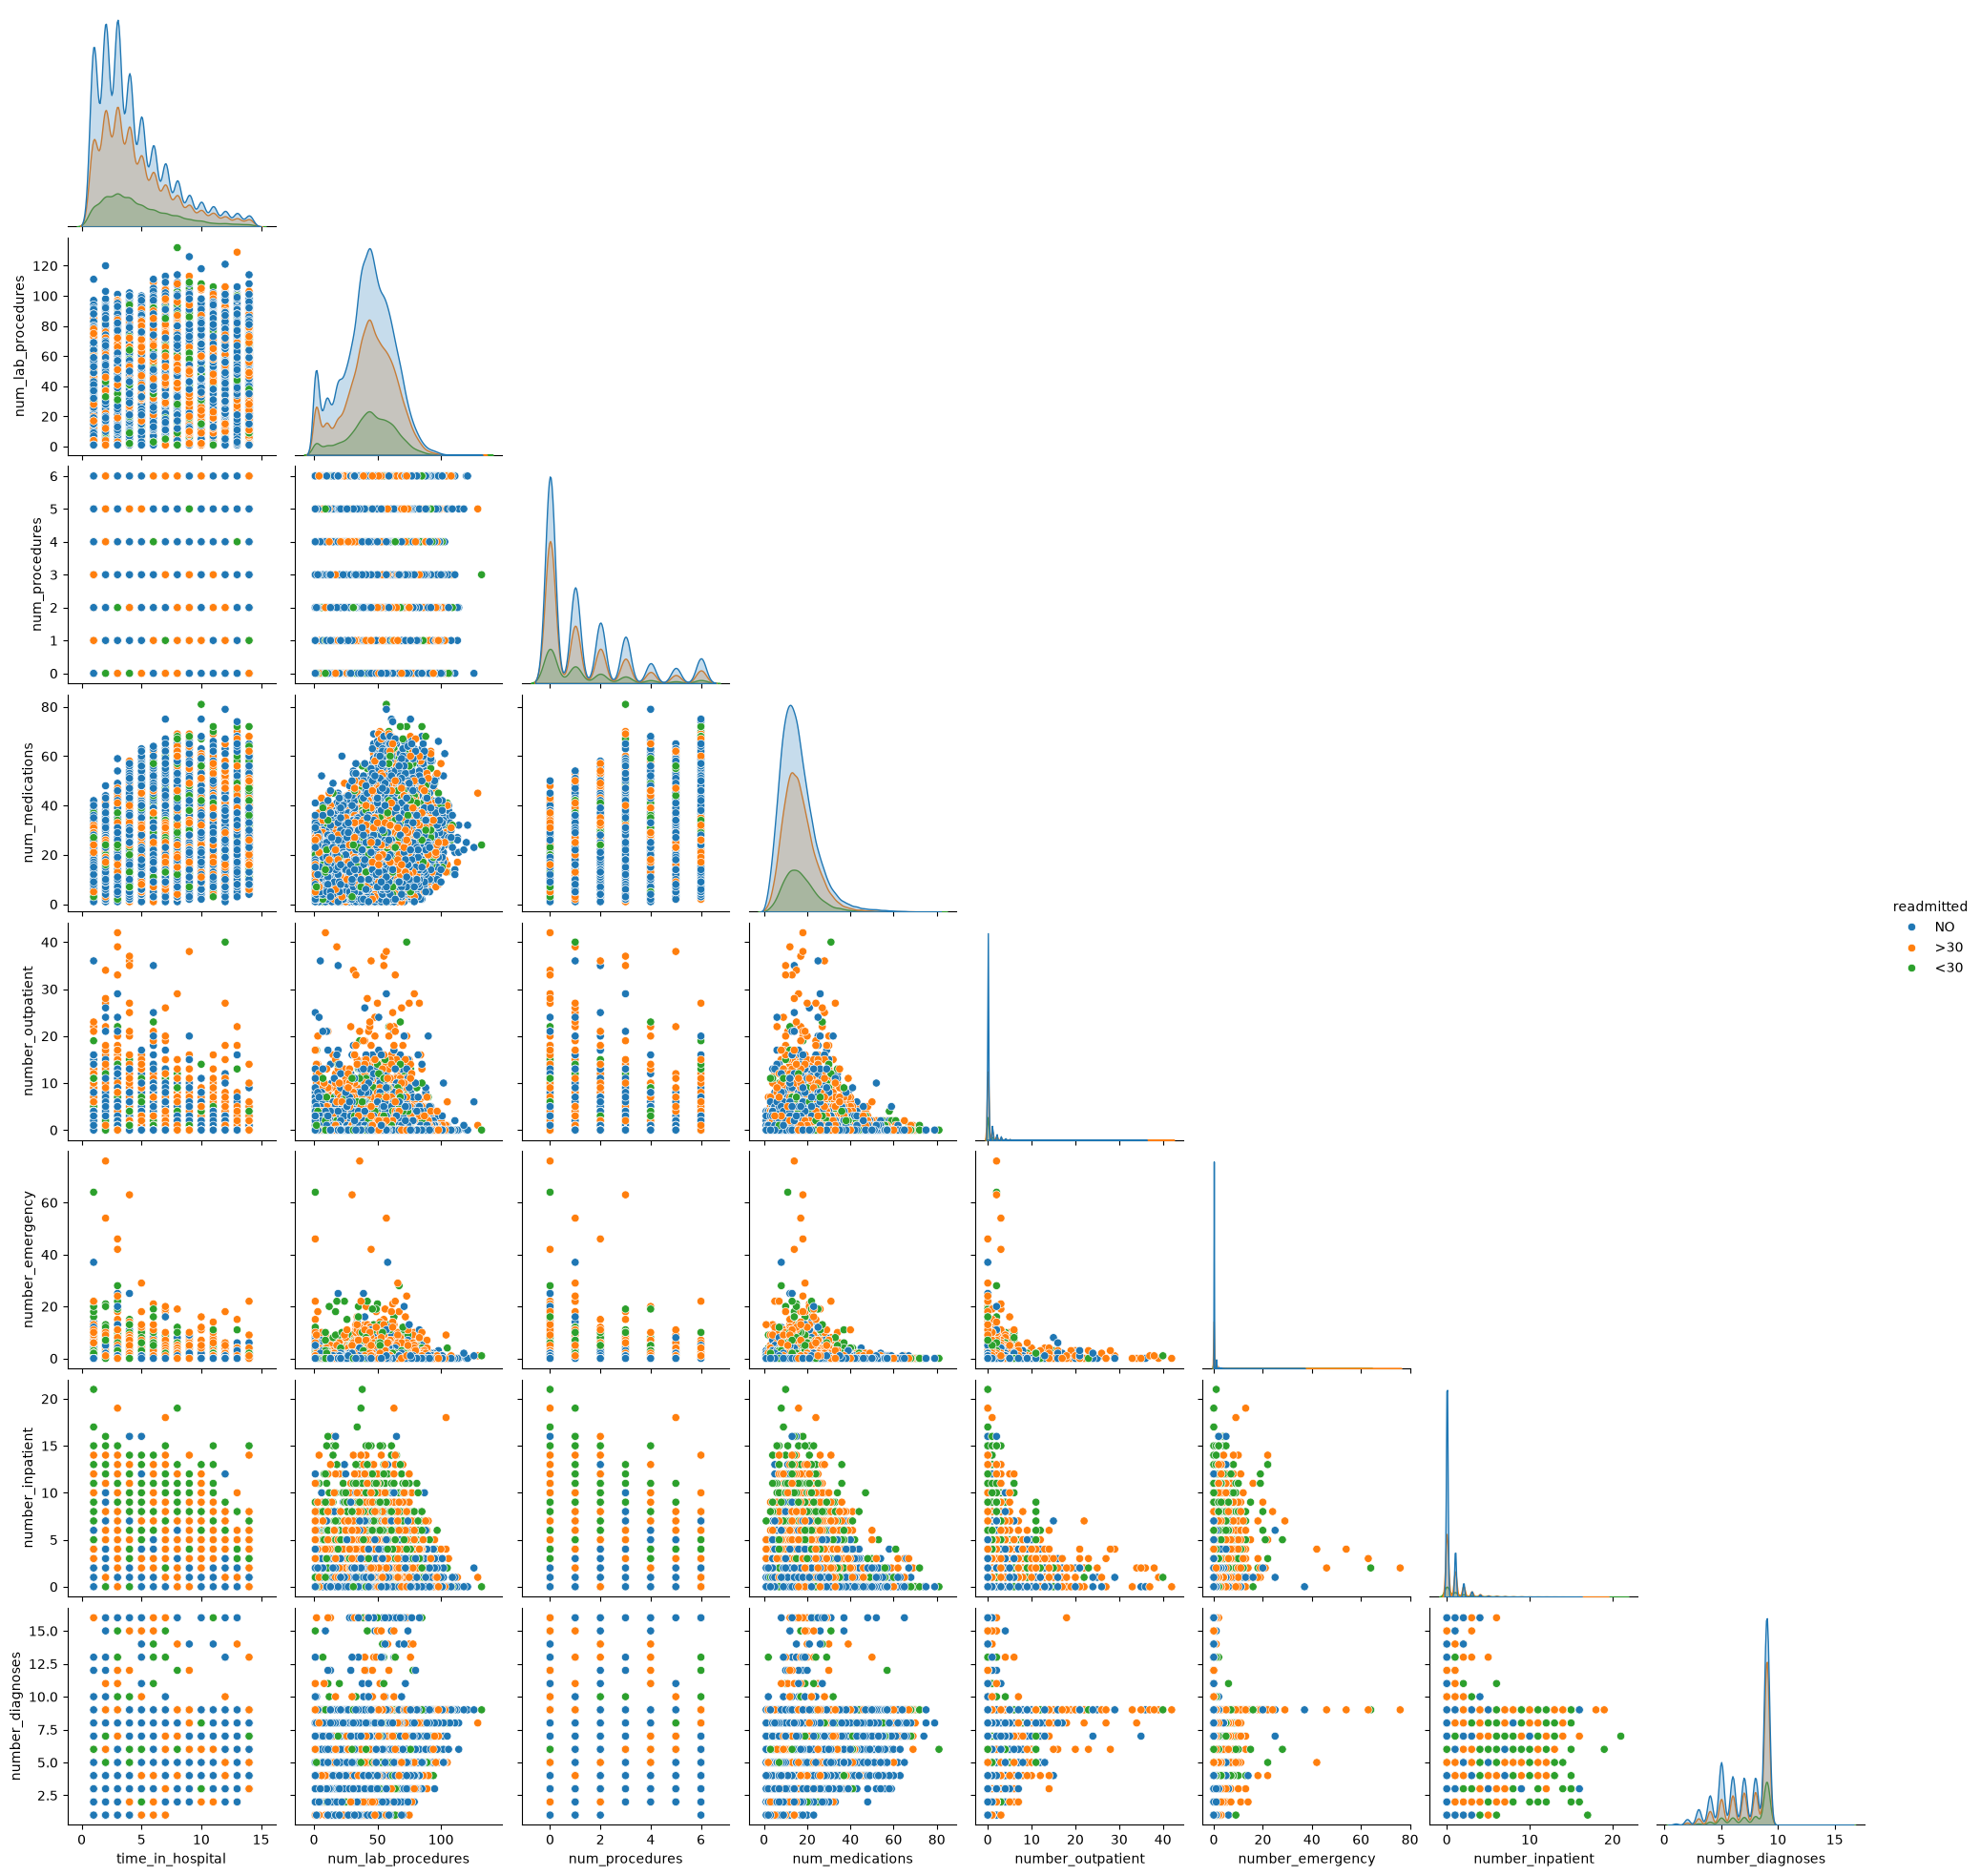

In [25]:
pairplot_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'readmitted'
]

sns.pairplot(df[pairplot_cols],hue='readmitted',corner=True)
plt.show()

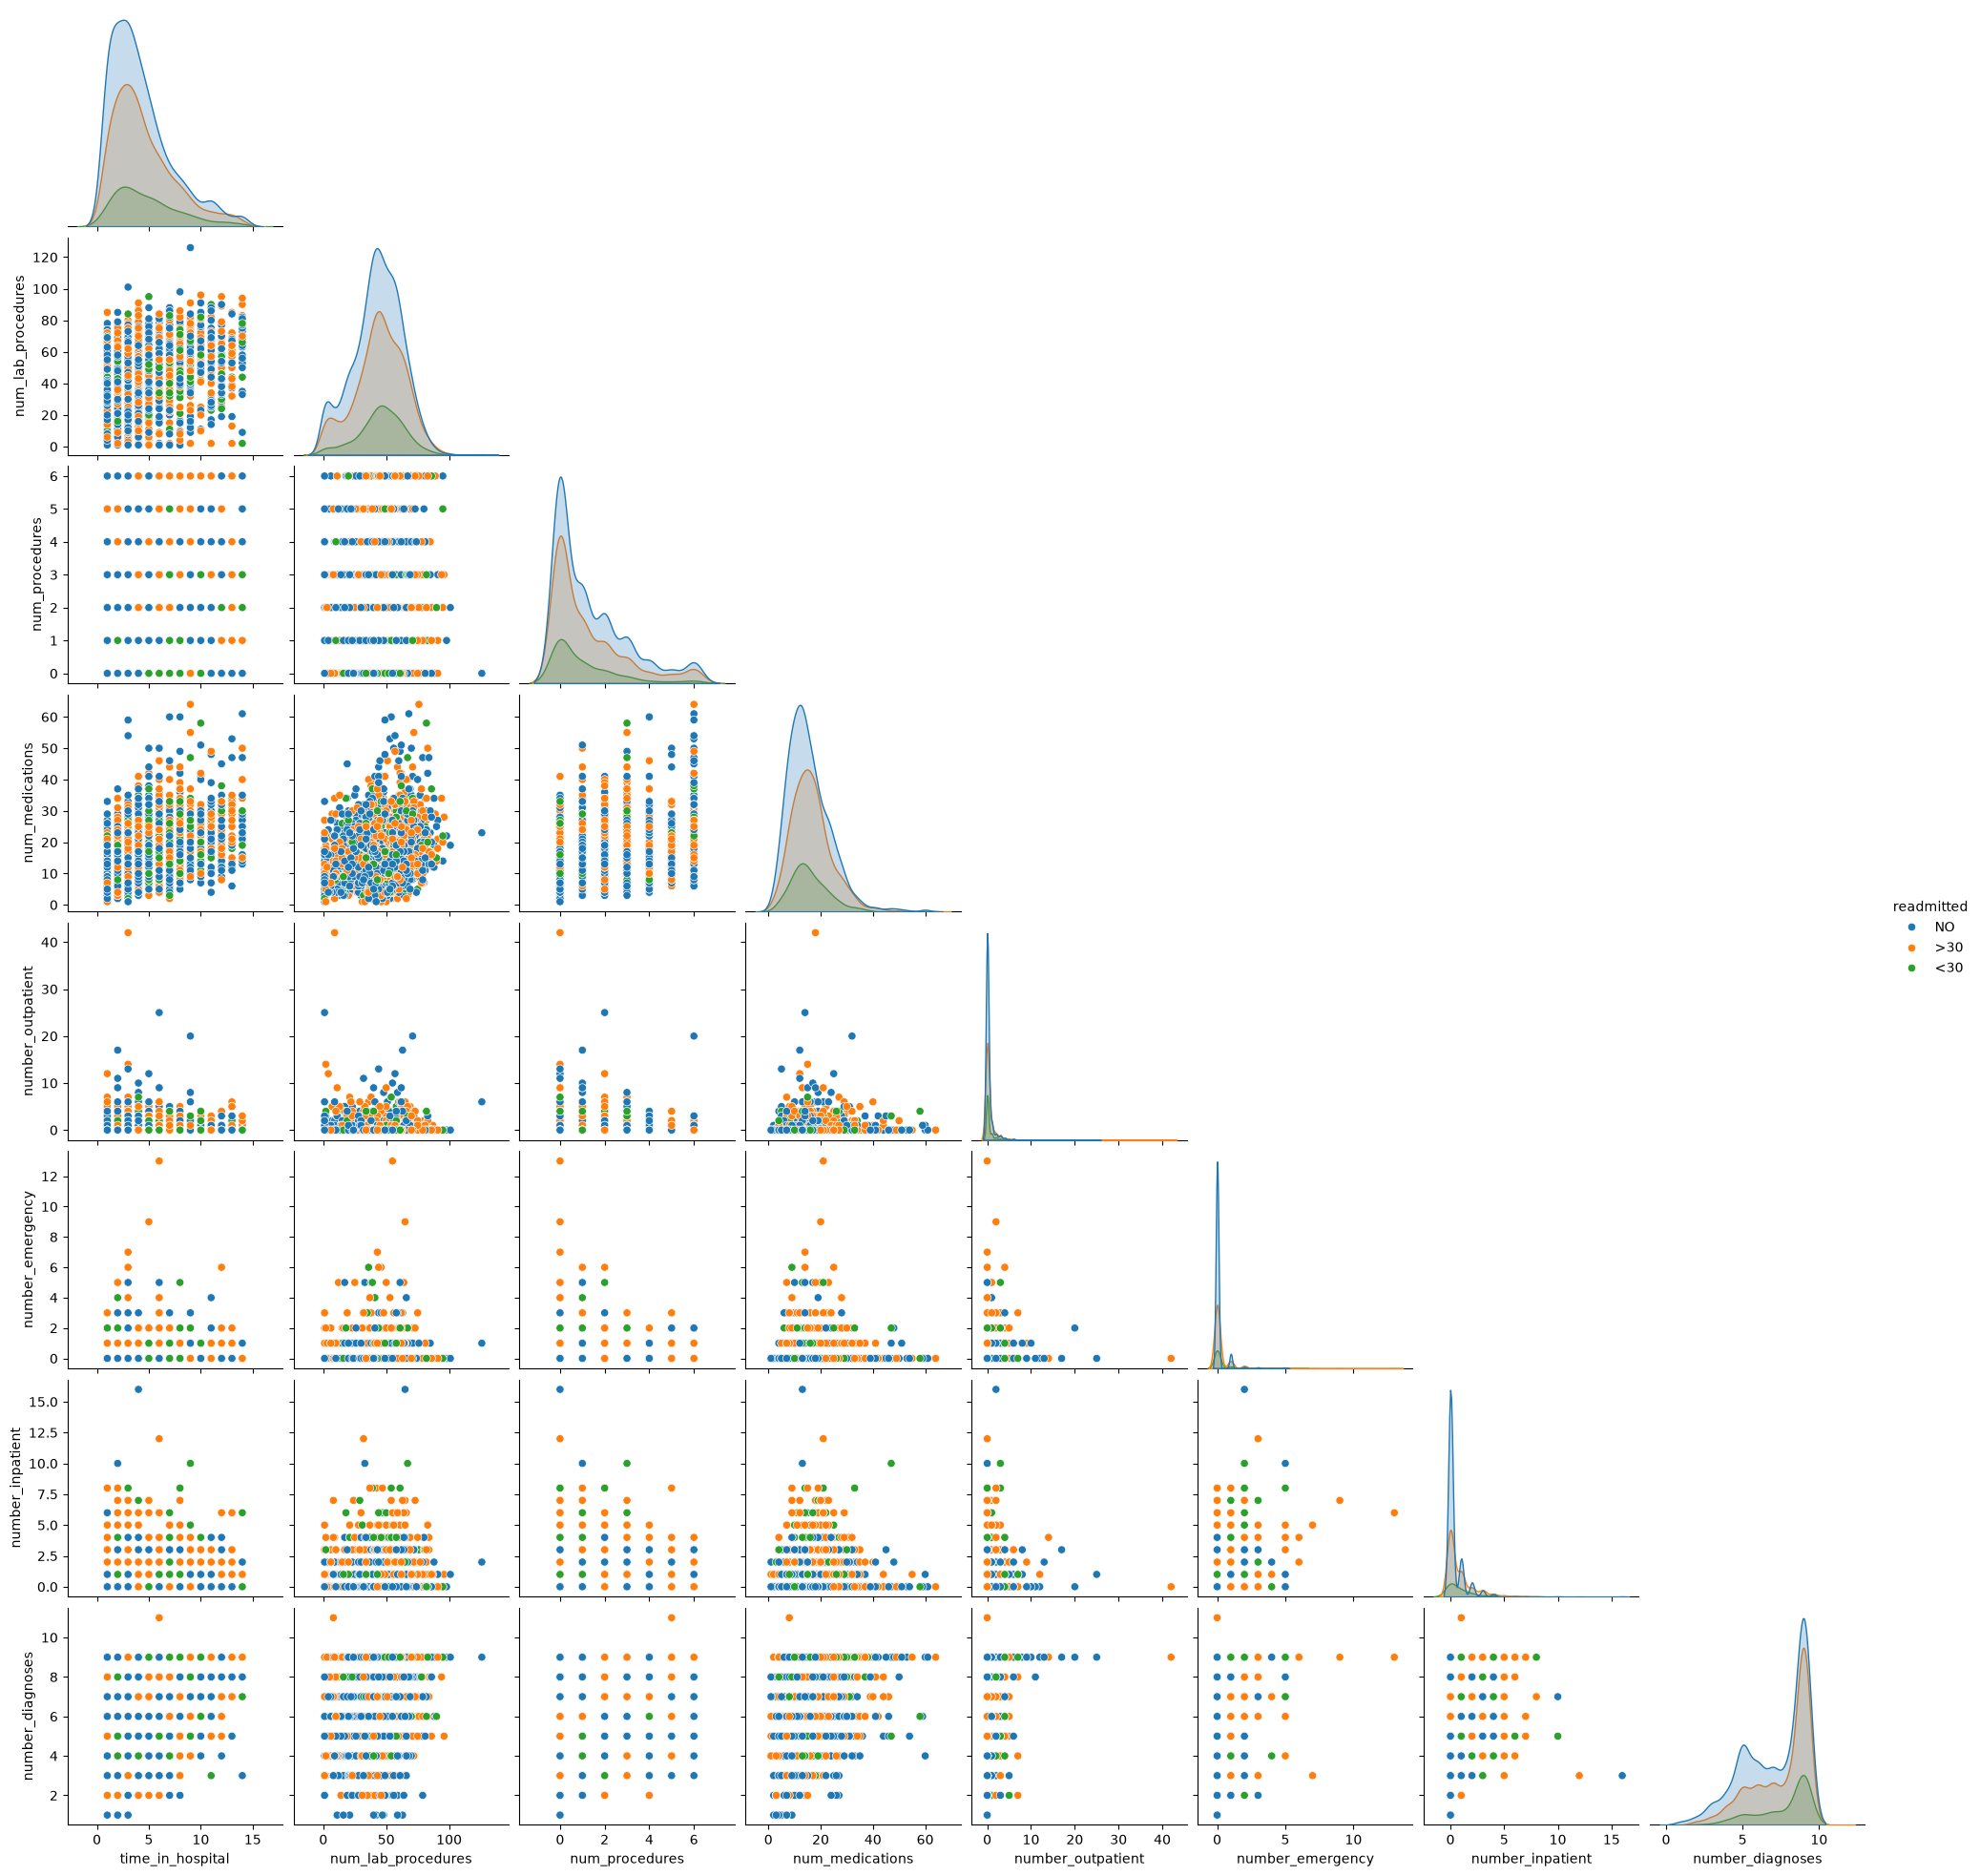

In [26]:
pairplot_data=df[pairplot_cols].sample(n=3000,random_state=42)

sns.pairplot(pairplot_data,hue='readmitted',corner=True)
plt.show()

In [27]:
outlier_summary=[]

for col in numerical_cols:
    
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    
    outliers=df[(df[col] < lower_bound)|(df[col] > upper_bound)]
    
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': len(outliers),
        'Outlier_Percentage': len(outliers) / len(df) * 100
    })

outlier_df=pd.DataFrame(outlier_summary)

outlier_df.sort_values(by='Outlier_Percentage',ascending=False)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
7,number_outpatient,0.0,0.0,0.0,0.0,0.0,16739,16.448519
8,number_emergency,0.0,0.0,0.0,0.0,0.0,11383,11.185465
1,discharge_disposition_id,1.0,4.0,3.0,-3.5,8.5,9818,9.647623
9,number_inpatient,0.0,1.0,1.0,-1.5,2.5,7049,6.926675
2,admission_source_id,1.0,7.0,6.0,-8.0,16.0,6956,6.835289
5,num_procedures,0.0,2.0,2.0,-3.0,5.0,4954,4.868031
6,num_medications,10.0,20.0,10.0,-5.0,35.0,2557,2.512627
3,time_in_hospital,2.0,6.0,4.0,-4.0,12.0,2252,2.212920
0,admission_type_id,1.0,3.0,2.0,-2.0,6.0,341,0.335082
10,number_diagnoses,6.0,9.0,3.0,1.5,13.5,281,0.276124


In [28]:
skewness=df[numerical_cols].skew().sort_values(ascending=False)

skewness_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})
skewness_df

,Feature,Skewness
0,number_emergency,22.855582
1,number_outpatient,8.832959
2,number_inpatient,3.614139
3,discharge_disposition_id,2.563067
4,admission_type_id,1.591984
5,num_medications,1.326672
6,num_procedures,1.316415
7,time_in_hospital,1.133999
8,admission_source_id,1.029935
9,num_lab_procedures,-0.236544


In [29]:
highly_skewed=skewness_df[abs(skewness_df['Skewness'])>1]

highly_skewed

,Feature,Skewness
0,number_emergency,22.855582
1,number_outpatient,8.832959
2,number_inpatient,3.614139
3,discharge_disposition_id,2.563067
4,admission_type_id,1.591984
5,num_medications,1.326672
6,num_procedures,1.316415
7,time_in_hospital,1.133999
8,admission_source_id,1.029935


## EDA Summary

The exploratory data analysis was performed to understand the structure,
distribution, missing values, relationships and potential issues in the
diabetes readmission dataset.

The main findings were:

1. The dataset contains more than 100,000 patient records and multiple
   demographic, clinical and medication-related features.

2. The target variable `readmitted` contains three classes:
   `NO`, `>30`, and `<30`, making this a multiclass classification problem.

3. The target classes are imbalanced, with the `NO` class representing
   the largest proportion of observations and `<30` representing the
   smallest class.

4. Several features contain missing values. These missing values will
   be handled during the preprocessing and feature engineering stage.

5. Numerical feature distributions were examined using histograms,
   KDE plots and boxplots.

6. Categorical features were analyzed using count plots and their
   relationship with readmission status was explored.

7. Correlation analysis was performed to identify relationships between
   numerical variables and possible redundant features.

8. Potential outliers and skewed numerical variables were identified
   for further consideration during preprocessing.

The findings from EDA will be used to guide feature engineering,
feature selection and machine learning model development.

## Feature Engineering & Preprocessing

In [30]:
ml_df=df.copy()
print("Original shape",df.shape)
print("ML dataset shape",ml_df.shape)

Original shape (101766, 47)
ML dataset shape (101766, 47)


In [31]:
ml_df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [32]:
trained_models=['encounter_id', 'patient_nbr', 'weight']

existing_id_columns=[
    col for col in trained_models
    if col in ml_df.columns
]

print("Columns to remove:", existing_id_columns)

Columns to remove: []


In [33]:
ml_df=ml_df.drop(columns=existing_id_columns,errors='ignore')

print("Shape after removing unnecessary columns:", ml_df.shape)

Shape after removing unnecessary columns: (101766, 47)


In [34]:
missing=ml_df.isnull().sum()
missing=missing[missing > 0].sort_values(ascending=False)
missing

max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [35]:
categorical_cols=ml_df.select_dtypes(include=['object', 'string']).columns
categorical_cols=categorical_cols.drop('readmitted', errors='ignore')

ml_df[categorical_cols]=ml_df[categorical_cols].fillna('Unknown')
print("Categorical columns:", len(categorical_cols))
print(categorical_cols.tolist())

Categorical columns: 35
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [36]:
ml_df.isnull().sum().sum()

np.int64(0)

In [37]:
missing_values = ml_df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [38]:
ml_df.dtypes.value_counts()

str      36
int64    11
Name: count, dtype: int64

In [39]:
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   admission_type_id         101766 non-null  int64
 4   discharge_disposition_id  101766 non-null  int64
 5   admission_source_id       101766 non-null  int64
 6   time_in_hospital          101766 non-null  int64
 7   payer_code                101766 non-null  str  
 8   medical_specialty         101766 non-null  str  
 9   num_lab_procedures        101766 non-null  int64
 10  num_procedures            101766 non-null  int64
 11  num_medications           101766 non-null  int64
 12  number_outpatient         101766 non-null  int64
 13  number_emergency          101766 non-null  int64
 14  number_inpatient          10176

In [40]:
X=ml_df.drop(columns=['readmitted'])
y=ml_df['readmitted']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 46)
y shape: (101766,)


In [41]:
numerical_features=X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features=X.select_dtypes(include=['object','string']).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 11
Categorical features: 35


In [42]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            'passthrough',
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)

Training data: (81412, 46)
Testing data: (20354, 46)


In [45]:
X_train_encoded=preprocessor.fit_transform(X_train)
X_test_encoded=preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (81412, 2367)
Encoded testing shape: (20354, 2367)


In [46]:
preprocessor.fit_transform(X_train)

array([[2., 7., 7., ..., 0., 0., 1.],
       [1., 1., 7., ..., 1., 0., 1.],
       [2., 1., 1., ..., 0., 0., 1.],
       ...,
       [2., 6., 1., ..., 1., 0., 1.],
       [1., 6., 7., ..., 0., 0., 1.],
       [3., 6., 2., ..., 0., 0., 1.]], shape=(81412, 2367))

In [47]:
preprocessor.transform(X_test)

array([[ 1.,  1.,  7., ...,  1.,  1.,  0.],
       [ 6.,  1., 17., ...,  1.,  0.,  1.],
       [ 1.,  3.,  7., ...,  0.,  0.,  1.],
       ...,
       [ 3.,  1.,  1., ...,  1.,  1.,  0.],
       [ 2.,  6.,  1., ...,  1.,  0.,  1.],
       [ 2.,  1.,  4., ...,  0.,  0.,  1.]], shape=(20354, 2367))

Feature Selection

In [48]:
feature_names=preprocessor.get_feature_names_out()
print("Total encoded features:", len(feature_names))

Total encoded features: 2367


Random Forest Feature

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_selector=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1,class_weight='balanced')
rf_selector.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [50]:
importance_df=pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_selector.feature_importances_
})

importance_df=importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
4,num__num_lab_procedures,0.045605
6,num__num_medications,0.043434
3,num__time_in_hospital,0.034159
9,num__number_inpatient,0.030206
10,num__number_diagnoses,0.025660
1,num__discharge_disposition_id,0.025539
5,num__num_procedures,0.023942
0,num__admission_type_id,0.017924
2,num__admission_source_id,0.015584
7,num__number_outpatient,0.012715


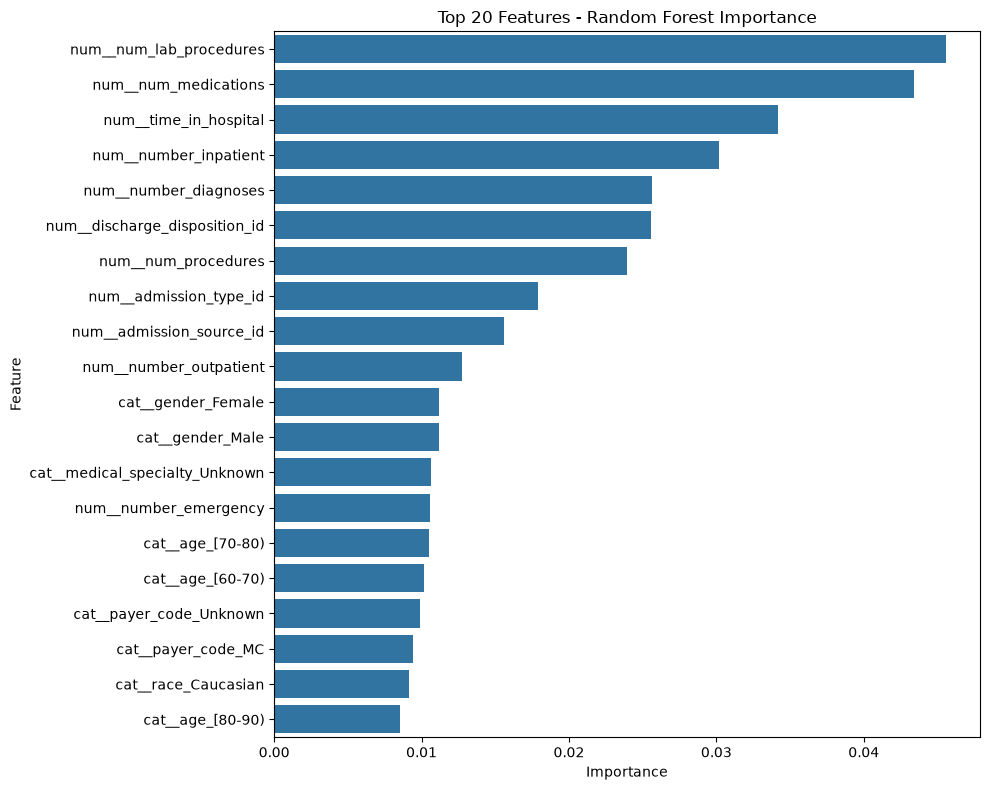

In [51]:
plt.figure(figsize=(10, 8))
top_features = importance_df.head(20)

sns.barplot(data=top_features,x='Importance',y='Feature')
plt.title("Top 20 Features - Random Forest Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

SelectKBest

In [52]:
from sklearn.feature_selection import VarianceThreshold,SelectKBest,f_classif

In [53]:
variance_selector=VarianceThreshold(threshold=0)
X_train_var=variance_selector.fit_transform(X_train_encoded)
X_test_var=variance_selector.transform(X_test_encoded)

print("Original encoded features:", X_train_encoded.shape[1])
print("After removing constant features:", X_train_var.shape[1])

k = 30
selector = SelectKBest(score_func=f_classif,k=k)

X_train_selected=selector.fit_transform( X_train_var,y_train)
X_test_selected=selector.transform(X_test_var)

print("Selected features:", X_train_selected.shape[1])

Original encoded features: 2367
After removing constant features: 2364
Selected features: 30


In [54]:
feature_names_var=feature_names[variance_selector.get_support()]
selected_features=feature_names_var[selector.get_support()]

print("Selected features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

Selected features:
1. num__discharge_disposition_id
2. num__admission_source_id
3. num__time_in_hospital
4. num__num_procedures
5. num__num_medications
6. num__number_outpatient
7. num__number_emergency
8. num__number_inpatient
9. num__number_diagnoses
10. cat__race_Unknown
11. cat__payer_code_BC
12. cat__medical_specialty_ObstetricsandGynecology
13. cat__diag_1_250.6
14. cat__diag_1_428
15. cat__diag_1_491
16. cat__diag_1_V58
17. cat__diag_2_250
18. cat__diag_2_401
19. cat__diag_2_403
20. cat__diag_3_250
21. cat__diag_3_401
22. cat__diag_3_403
23. cat__diag_3_585
24. cat__insulin_Down
25. cat__insulin_No
26. cat__insulin_Up
27. cat__change_Ch
28. cat__change_No
29. cat__diabetesMed_No
30. cat__diabetesMed_Yes


### Feature Scaling

In [55]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train_selected)
X_test_scaled=scaler.transform(X_test_selected)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (81412, 30)
Testing shape: (20354, 30)


In [56]:
scaler.fit_transform(X_train_selected)

array([[ 0.62053627,  0.30973563,  0.53859535, ..., -1.07777129,
        -0.54545986,  0.54545986],
       [-0.51428235,  0.30973563, -0.46754943, ...,  0.92784064,
        -0.54545986,  0.54545986],
       [-0.51428235, -1.17026185, -1.13831261, ..., -1.07777129,
        -0.54545986,  0.54545986],
       ...,
       [ 0.43139983, -1.17026185, -0.80293102, ...,  0.92784064,
        -0.54545986,  0.54545986],
       [ 0.43139983,  0.30973563, -0.46754943, ..., -1.07777129,
        -0.54545986,  0.54545986],
       [ 0.43139983, -0.9235956 ,  0.87397694, ..., -1.07777129,
        -0.54545986,  0.54545986]], shape=(81412, 30))

In [57]:
scaler.transform(X_test_selected)

array([[-0.51428235,  0.30973563,  0.20321376, ...,  0.92784064,
         1.83331548, -1.83331548],
       [-0.51428235,  2.7763981 ,  0.53859535, ...,  0.92784064,
        -0.54545986,  0.54545986],
       [-0.13600948,  0.30973563,  1.20935854, ..., -1.07777129,
        -0.54545986,  0.54545986],
       ...,
       [-0.51428235, -1.17026185, -1.13831261, ...,  0.92784064,
         1.83331548, -1.83331548],
       [ 0.43139983, -1.17026185,  0.53859535, ...,  0.92784064,
        -0.54545986,  0.54545986],
       [-0.51428235, -0.43026311, -0.80293102, ..., -1.07777129,
        -0.54545986,  0.54545986]], shape=(20354, 30))

### ML Models

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [59]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [60]:
trained_models={}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train_scaled,
        y_train
    )

    trained_models[name]=model

    print(f"{name} completed.\n")

print("All models trained successfully!")

Training Logistic Regression...
Logistic Regression completed.

Training Decision Tree...
Decision Tree completed.

Training Random Forest...
Random Forest completed.

Training KNN...
KNN completed.

Training Gradient Boosting...
Gradient Boosting completed.

All models trained successfully!


Model Evaluation

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results=[]

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
4,Gradient Boosting,0.586469,0.550419,0.586469,0.534561
2,Random Forest,0.547853,0.511187,0.547853,0.521973
3,KNN,0.507026,0.493526,0.507026,0.499539
0,Logistic Regression,0.488160,0.515510,0.488160,0.494738
1,Decision Tree,0.472389,0.480872,0.472389,0.476378


Confusion Matrix

In [62]:
from sklearn.metrics import classification_report

best_model=trained_models["Gradient Boosting"]

y_pred_gb=best_model.predict(X_test_scaled)

print(classification_report(
    y_test,
    y_pred_gb,
    zero_division=0
))

              precision    recall  f1-score   support

         <30       0.38      0.02      0.04      2272
         >30       0.51      0.35      0.41      7109
          NO       0.61      0.86      0.72     10973

    accuracy                           0.59     20354
   macro avg       0.50      0.41      0.39     20354
weighted avg       0.55      0.59      0.53     20354



Confusion Matrix

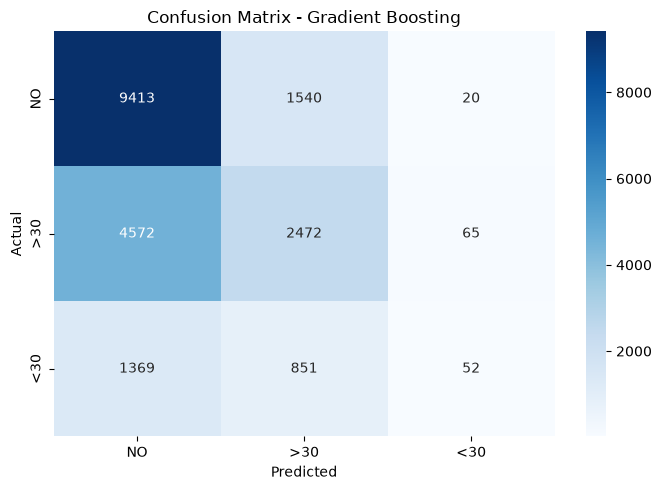

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_gb,
    labels=['NO', '>30', '<30']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NO', '>30', '<30'],
    yticklabels=['NO', '>30', '<30']
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

Hyperparameter Tuning

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

In [65]:
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid,
    n_iter=6,            
    scoring='f1_weighted',
    cv=2,             
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

Fitting 2 folds for each of 6 candidates, totalling 12 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [66]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1 Score:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.1}

Best CV F1 Score:
0.5368880206928125


In [68]:
best_gb = random_search.best_estimator_

y_pred_tuned = best_gb.predict(X_test_scaled)

print(classification_report(
    y_test,
    y_pred_tuned,
    zero_division=0
))

              precision    recall  f1-score   support

         <30       0.38      0.02      0.05      2272
         >30       0.51      0.36      0.42      7109
          NO       0.62      0.85      0.71     10973

    accuracy                           0.59     20354
   macro avg       0.50      0.41      0.39     20354
weighted avg       0.55      0.59      0.54     20354



In [69]:
tuned_f1=f1_score(
    y_test,
    y_pred_tuned,
    average='weighted'
)

print("Tuned Gradient Boosting F1 Score:", tuned_f1)

Tuned Gradient Boosting F1 Score: 0.536725682956547


In [70]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

print("Sample weights created.")

Sample weights created.


In [71]:
from sklearn.ensemble import GradientBoostingClassifier

gb_balanced = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42
)

gb_balanced.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weights
)

print("Balanced Gradient Boosting trained.")

Balanced Gradient Boosting trained.


In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred_balanced = gb_balanced.predict(X_test_scaled)

print("Balanced Gradient Boosting Results")
print("-----------------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(
    y_test, y_pred_balanced,
    average='weighted',
    zero_division=0
))
print("Recall   :", recall_score(
    y_test, y_pred_balanced,
    average='weighted',
    zero_division=0
))
print("F1 Score :", f1_score(
    y_test, y_pred_balanced,
    average='weighted',
    zero_division=0
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_balanced,
    zero_division=0
))

Balanced Gradient Boosting Results
-----------------------------------
Accuracy : 0.5018178245062396
Precision: 0.5501188480321331
Recall   : 0.5018178245062396
F1 Score : 0.5183478078135546

Classification Report:
              precision    recall  f1-score   support

         <30       0.20      0.43      0.28      2272
         >30       0.46      0.38      0.42      7109
          NO       0.68      0.59      0.63     10973

    accuracy                           0.50     20354
   macro avg       0.45      0.47      0.44     20354
weighted avg       0.55      0.50      0.52     20354



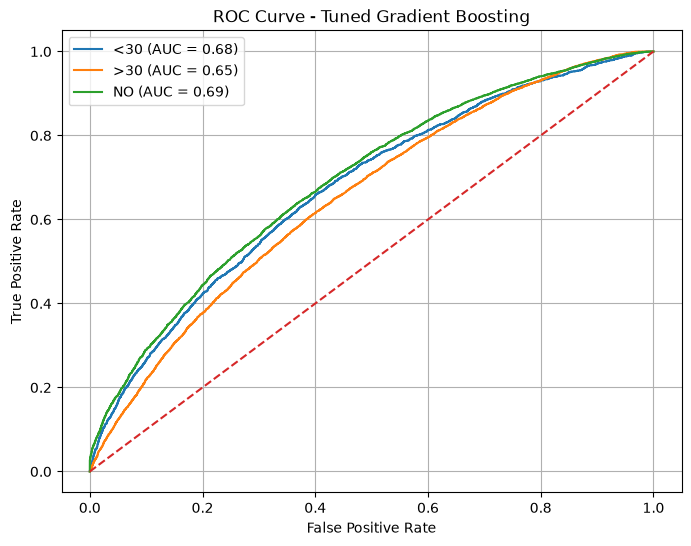

In [73]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = ['<30', '>30', 'NO']

y_test_bin = label_binarize(y_test, classes=classes)

y_score = best_gb.predict_proba(X_test_scaled)
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_name} (AUC = {roc_auc:.2f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Gradient Boosting")
plt.legend()
plt.grid()
plt.show()